# Diagnóstico de Hipertireoidismo - Análise Exploratória de Dados

## Contexto do Problema

Hospital e médicos enfrentam dilemas diários no diagnóstico do hipertireoidismo. O diagnóstico tardio traz inúmeras complicações, além de sintomas similares a outras condições de saúde.

O hipertireoidismo tardio (ou não tratado) apresenta sintomas como taquicardia, que pode ser visualizada em quadros de ansiedade, desidratação, infecções, entre outros. O médico ao decidir o tratamento incorreto por dúvida entre patologias diferentes, como tratar taquicardia de hipertireoidismo com ansiolíticos, não mostra resultado nenhum na condição e a tireoide continua em negligência.

Assim resulta em agravamento da condição do paciente, desperdício de recursos médicos e tempo. Desenvolver um modelo preditivo para o diagnóstico preciso é fundamental para o tratamento correto, reduzindo custos e melhorando a qualidade de vida dos pacientes.

## Objetivo

Desenvolver um modelo de classificação para prever o diagnóstico de hipertireoidismo com base em exames laboratoriais e histórico médico dos pacientes.

## Dataset

- Fonte: Base_M43_Pratique_Hypothyroid.csv
- Volume: 3.772 registros, 30 variáveis
- Target: `binaryClass` (P = positivo, N = negativo)

## Metodologia

Este notebook segue o EDA Framework em 4 camadas:

1. Reconhecimento: dimensões, tipos, missings, inconsistências
2. Distribuição: análise univariada de cada variável
3. Relação com o Target: poder preditivo de cada feature
4. Multivariada: correlações, redundâncias, feature engineering

## Como Navegar

Execute as células em ordem sequencial. Cada bloco de código é seguido de uma célula Markdown com interpretação e conclusões. Decisões de pré-processamento são documentadas mas aplicadas no notebook `02_preprocessing.ipynb`.

In [ ]:
# bibliotecas
import pandas as pd                         # manipulação dos dados
import numpy as np                          # suporte de calculos
import matplotlib.pyplot as plt             # visualização grafica
from matplotlib import axes                 # visualização grafica multipla
import seaborn as sns                       # visualização grafica avançada
import plotly.express as px                 # visualização grafica Interativa
from matplotlib.ticker import FuncFormatter # auxiliar visualização do plt/sns
from scipy.stats import chi2_contingency    #Cramer_v - para vericar elação entre variaveis categoricas

In [ ]:
# configurações
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') # demonstra numeros no pandas em float
formatter = FuncFormatter(lambda x, _: f'{int(x):,}') # Formatter que converte o número para inteiro legível

In [ ]:

#df = pd.read_csv('../data/raw/Base_M43_Pratique_Hypothyroid.csv', sep=',')
#df.head()

In [ ]:
df = pd.read_csv('Base_M43_Pratique_Hypothyroid.csv', sep=',')
display(df.head())
display(df.tail())
print(f'Colunas: {df.columns.tolist()}')
print(df.shape)

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
3767,30,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,f,?,other,P
3768,68,F,f,f,f,f,f,f,f,f,...,t,124,t,1.08,t,114,f,?,SVI,P
3769,74,F,f,f,f,f,f,f,f,f,...,t,112,t,1.07,t,105,f,?,other,P
3770,72,M,f,f,f,f,f,f,f,f,...,t,82,t,0.94,t,87,f,?,SVI,P
3771,64,F,f,f,f,f,f,f,f,f,...,t,99,t,1.07,t,92,f,?,other,P


Colunas: ['age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source', 'binaryClass']
(3772, 30)


## Camada 1 - Reconhecimento
- numeros de linhas e colunas
- tipos de variaveis estao corretos?
- valores faltantes ?

### Variáveis
Com a visualuzação resolvi olhar a fundo aque se refere cada dimensão um das dimensões do dataset

| Variável | Tipo | Descricao |
|---|---|---|
| age | Numérica | Idade do paciente |
| sex | Categórica | Sexo do paciente |
| on thyroxine | Categórica | Paciente em uso de tiroxina |
| query on thyroxine | Categórica | Consulta sobre tiroxina |
| on antithyroid medication | Categórica | Uso de medicamento antitireoidiano |
| sick | Categórica | Paciente doente |
| pregnant | Categórica | Paciente gravida |
| thyroid surgery | Categórica | Cirurgia de tireoide previa |
| I131 treatment | Categórica | Tratamento com Iodo-131 |
| query hypothyroid | Categórica | Consulta de hipotireoidismo |
| query hyperthyroid | Categórica | Consulta de hipertireoidismo |
| lithium | Categórica | Uso de litio |
| goitre | Categórica | Presenca de bocio |
| tumor | Categórica | Presenca de tumor |
| hypopituitary | Categórica | Hipopituitarismo |
| psych | Categórica | Condicao psiquiatrica |
| TSH measured | Categórica | TSH foi medido |
| TSH | Numérica | Valor do TSH |
| T3 measured | Categórica | T3 foi medido |
| T3 | Numérica | Valor do T3 |
| TT4 measured | Categórica | TT4 foi medido |
| TT4 | Numérica | Valor do TT4 |
| T4U measured | Categórica | T4U foi medido |
| T4U | Numérica | Valor do T4U |
| FTI measured | Categórica | FTI foi medido |
| FTI | Numérica | Valor do FTI |
| TBG measured | Categórica | TBG foi medido |
| TBG | Numérica | Valor do TBG |
| referral source | Categórica | Origem do encaminhamento |
| binaryClass | Categórica | Target - Diagnostico (P/N) |

### Limitação - Unidades de Medida dos Exames

As unidades de medida das variáveis de exame (TSH, T3, TT4, T4U, FTI) não estão documentadas no dataset. Valores de TSH chegando a 530 estão acima da faixa esperada para mU/L (0.5 a 4.5), sugerindo possível uso de unidade diferente ou casos de hipotireoidismo severo não tratado.

**Risco em produção:** se o modelo for treinado com dados em uma unidade e em produção os dados chegarem em outra unidade, as predições serão incorretas.

**Recomendação:** confirmar com o stakeholder as unidades de medida utilizadas na coleta antes de implantar o modelo em produção.

In [ ]:
# visao geral consolidada conjunto
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

In [ ]:
# visualiza unicos nas categorias
df.nunique()

,0
age,94
sex,3
on thyroxine,2
query on thyroxine,2
on antithyroid medication,2
sick,2
pregnant,2
thyroid surgery,2
I131 treatment,2
query hypothyroid,2


#### Situação Observada

algumas colunas apresentam um número estranha para as categorias
- 'sex' = 3
- TBG measured = 1
- TBG = 1

irei verificar todos os valores unicos das colunas para melhor entendimento


In [ ]:
# verifica todos os valores unicos nas colunas
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

age: ['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' '?' '93' '92']
sex: ['F' 'M' '?']
on thyroxine: ['f' 't']
query on thyroxine: ['f' 't']
on antithyroid medication: ['f' 't']
sick: ['f' 't']
pregnant: ['f' 't']
thyroid surgery: ['f' 't']
I131 treatment: ['f' 't']
query hypothyroid: ['f' 't']
query hyperthyroid: ['f' 't']
lithium: ['f' 't']
goitre: ['f' 't']
tumor: ['f' 't']
hypopituitary: ['f' 't']
psych: ['f' 't']
TSH measured: ['t' 'f']
TSH: ['1.3' '4.1' '0.98' '0.16' '0.72' '0.03' '?' '2.2' '0.6' '2.4' '1.1' '2.8'
 '3.3' '12' '1.2' '1.5' '6' '2.1' '0.1' '0.8' '1.9' '3.1' '0.2' '1

### Ajustes necessários

algumas ações devem ser tomadas antes de aprofundar a analise pois temos várias informações faltantes, documentadas:

|Problema  | Ação                             | Justificativa            |
|----------|----------------------------------|-------------------------|
|`Age` - em valores como `?` e outliers impossivel | verificar impacto dos problemas na bases <br> e verificar se a imputação ou remoção pode <br> enviesar o modelo | é categoria que pode ter bastente relação com a Target,<br> assim é necessario maior aprofundamento antes da decisão <br> ser tomada e executada |
| `sex` - possui `?` | verificar a quantidade de items e imputar<br> com a moda se número de impactos for baixo | é uma categoria que pode ser importante mas tambem pode ter<br> uma relevancia menor com relação ao target, então preencher <br>com a moda pode manter outras informações relevantes|
| `TSH`-`T3`-`TT4`-`T4U`-`FTI`possui valores não coletados <br> e prenchidos como `?` | imputação dos valores não coletados por `NaN` |  decisão de colocar como nulos e não `0`, pois não são informações<br> faltantes mas sim não coletadas, o que pode indicar decisões médicas<br> implicitas e imformações válidas com a não coleta, visto que o preencher<br> com zero pode indicar um resultado que seria válido ao invés de não<br> significar nada |
| `TBG` e `TBG Measured` tem somente informações não coletas e nulas| remover as variaveis da base    | Colunas que não possui informação relevando e não podem ser<br> preenchidas de nenhuma forma a nãoser retornar a coleta dos dados|

Seguirei com as ações antes da antes de continuar a análise, exploratória


In [ ]:
#drop das colunas TBG e TBG Measured
df_pretratado = df.drop(columns=['TBG', 'TBG measured'], axis=1)

In [ ]:
# Verificar valores nulos em age e linha com outliers
print(df[(df['age'] == '?') | (pd.to_numeric(df['age'], errors='coerce') >= 120)].shape[0])

2


In [ ]:
# visuliza as linhas com falhas
df[(df['age'] == '?') | (pd.to_numeric(df['age'], errors='coerce') >= 120)]

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
1364,455,F,f,f,f,f,f,f,f,f,...,t,118,t,1.13,t,104,f,?,SVI,P
1985,?,F,t,f,f,f,f,f,t,f,...,t,120,t,0.82,t,146,f,?,other,P


#### ação final de age

imputar com a media/mediana para manter as informações, achei interessante manter pois são dois positivos informações diferentes na coletas medicas e baixa, e como é um percentual muito pequeno a chance de enviesar o modelo é baixa

In [ ]:
# visualiza 'Age' como numerico
pd.to_numeric(df['age'], errors='coerce').describe()

,age
count,"3,771.00"
mean,51.74
std,20.08
min,1.00
25%,36.00
50%,54.00
75%,67.00
max,455.00


In [ ]:
# Verificar valores nulos em sex e linha com outliers
null_sex = df[df['sex'] == '?'].shape[0]
male = df[df['sex'] == 'M'].shape[0]
female = df[df['sex'] == 'F'].shape[0]

print(f"nulos: {null_sex}\n M: {male}\n F: {female}")

null_sex_perc = (null_sex / len(df) * 100)

print(f"nulos: {null_sex}\n percentual: {null_sex_perc:.2f}" )


nulos: 150
 M: 1142
 F: 2480
nulos: 150
 percentual: 3.98


In [ ]:
# visualiza distribuição da variavel sex
pd.crosstab(df['sex'], df['binaryClass'], normalize='index')

binaryClass,N,P
sex,,
?,0.07,0.93
F,0.09,0.91
M,0.06,0.94


#### Ação final para sex

imputar com a moda os 150 faltantes, pois numero de falta é bem baixo corresponde a 3.98%, então tem baixo poder de enviasar o modelo furamente.

Vale a menção que foi possivel verificar que que a base para homens e mulheres com relação ao target está bem desbalanceada, veiricar mais profundamente a relação com o target nas proximas camadas, mas devera ser tratado no tramento dos dados o desbalnceamento.

|sex |  N | P  | Quantidades |
|----|----|----|-------------|
|?	 |0.07|0.93|     150     |
|F	 |0.09|0.91|     2480    |
|M	 |0.06|0.94|     1142    |


In [ ]:
# replace das caracteres ? como nulos no df tratado anteriomente para remoção das
df_pretratado.replace('?', np.nan, inplace=True)
#transforma em numericos
cols_numericas = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
df_pretratado[cols_numericas] = df_pretratado[cols_numericas].apply(pd.to_numeric, errors='coerce')

In [ ]:
# transforma outliers de age em nulo
df_pretratado['age'] = df_pretratado['age'].replace(455, np.nan)
# calcula mediana age
median = df_pretratado['age'].median()
# imputa a mediana nos nulos de age
df_pretratado['age'] = df_pretratado['age'].fillna(median)

print(f'Mediana de idade:{median} \nQuantidade de nulos: {df_pretratado["age"].isna().sum()}')

Mediana de idade:54.0 
Quantidade de nulos: 0


In [ ]:
# calcula Moda da variaveis 'sex'
moda_sex = df_pretratado['sex'].mode()[0]
# imputa com a moda
df_pretratado['sex'] = df_pretratado['sex'].fillna(moda_sex)

print(f'Valores unicos{df_pretratado['sex'].unique()} \nModa da variável: {moda_sex} \nQuantidade de nulos: {df_pretratado['sex'].isna().sum()}')

Valores unicos['F' 'M'] 
Moda da variável: F 
Quantidade de nulos: 0


In [ ]:
# visao geral de nulos do conjunto
df_pretratado.isnull().sum()

,0
age,0
sex,0
on thyroxine,0
query on thyroxine,0
on antithyroid medication,0
sick,0
pregnant,0
thyroid surgery,0
I131 treatment,0
query hypothyroid,0


In [ ]:
#visao geral do valores
df_pretratado.describe()

,age,TSH,T3,TT4,T4U,FTI
count,"3,772.00","3,403.00","3,003.00","3,541.00","3,385.00","3,387.00"
mean,51.63,5.09,2.01,108.32,0.99,110.47
std,18.98,24.52,0.83,35.60,0.20,33.09
min,1.00,0.01,0.05,2.00,0.25,2.00
25%,36.00,0.50,1.60,88.00,0.88,93.00
50%,54.00,1.40,2.00,103.00,0.98,107.00
75%,67.00,2.70,2.40,124.00,1.08,124.00
max,94.00,530.00,10.60,430.00,2.32,395.00


## Conclusao do Reconhecimento

Ao realizar o reconhecimento inicial do dataset, todas as variaveis foram carregadas como categoricas. Durante a preparacao para analise, foram identificados dados faltantes em diversas colunas, representados pelo placeholder `?`.

---

### Dados Faltantes Identificados

| Variavel | Nulos | Observacao |
|---|:---:|---|
| `age` | 1 | Placeholder `?` + outlier identificado |
| `sex` | ~150 | Placeholder `?` |
| `TSH` | 369 | Placeholder `?` |
| `T3` | 769 | Placeholder `?` |
| `TT4` | 231 | Placeholder `?` |
| `T4U` | 387 | Placeholder `?` |
| `FTI` | 385 | Placeholder `?` |
| `TBG` | todos | Completamente nulo |
| `TBG measured` | todos | Completamente nulo |

---

### Decisoes Tomadas

**Remocao de colunas**
- `TBG` e `TBG measured` removidas integralmente — impossivel realizar imputacao sem dados de referencia para geracao de valores ao modelo.

**Tratamento do placeholder**
- Todos os valores `?` convertidos para `NaN` — necessario para que o pandas reconheca os nulos corretamente e permita conversao dos tipos das colunas.

**Imputacao de `age`**
- Linhas com nulo e outlier removidas — representavam percentual insignificante da base. Mediana utilizada como criterio, visto que o outlier e o nulo estavam distorcendo a media.

**Imputacao de `sex`**
- Nulos imputados com a **moda** — representavam menos de 4% da base. Moda escolhida para enviesar o minimo possivel o modelo, dado o baixo impacto preditivo da variavel.

**Manutencao dos nulos em exames laboratoriais**
- `TSH`, `T3`, `TT4`, `T4U` e `FTI` com nulos **mantidos intencionalmente** — a ausencia de valor representa uma **decisao medica de nao coletar o exame**, carregando informacao clinica relevante. Essas variaveis serao tratadas nas analises individuais para entender melhor seu impacto no modelo.

### Observacoes para Investigacao Futura

- **Nulos informativos nos exames:** a ausencia de coleta em TSH, T3, TT4, T4U e FTI nao e aleatoria. Representa decisao medica consciente, o que pode indicar subgrupos de pacientes com perfis clinicos distintos. A ser investigado nas camadas 3 e 4.

- **Padrao de coleta pareado:** cada exame possui uma coluna `measured` correspondente (ex: `TSH measured` / `TSH`). Esse padrao estrutural sugere que a flag de coleta pode carregar informacao preditiva independente do valor do exame. A ser verificado na camada 3.

- **TBG completamente ausente:** a remocao de TBG e TBG measured elimina uma variavel potencialmente relevante clinicamente. Limitacao do dataset sem possibilidade de recuperacao.

- **Age como outlier extremo:** valor de 455 identificado indica possivel erro de coleta ou digitacao. Tratado como nulo e imputado pela mediana, mas levanta questionamento sobre a qualidade geral dos dados numericos da base.

## Camada 2 - Distribuição univariada

- como cada variavel se comporta sozinha
- como é a distribuição?
- valores impossiveis?

### Análise da variavel age

In [ ]:
# visualização de possiveis outliers

fig = px.box(df_pretratado,
             y='age',
             points='all',
             )
fig.show()

In [ ]:
# visualiza distribuição das idades

fig = px.histogram(df_pretratado,
                   x='age',
                   title='Distribuição de Idades',
                  )

fig.show()

In [ ]:
# analise de simetria

df_pretratado['age'].skew()

np.float64(-0.21109583221771885)

### Conclusão de Age

Distribuição aproximadamente simétrica (skewness = -0.21), com leve assimetria à esquerda. Pico de concentração entre 55-60 anos, cauda um pouco mais longa nos valores baixos.

**Tratamento aplicado:** outlier (455) e nulo (`?`) substituídos pela mediana (54), por representarem percentual irrelevante da base.

**Hipótese para camada 3:** a doença é mais prevalente em adultos de meia-idade para mais velhos, dado que a concentração de pacientes nessa faixa etária é maior.

### Análise da variavel sex

In [ ]:
# Contagem valores de df[sex]
valores_sex__vazios = (df['sex'].value_counts(normalize=True)*100)
# Contagem valores de df_pretratado[sex]
valores_sex__prenchidos = (df_pretratado['sex'].value_counts(normalize=True)*100)

# ver as contagens
print(valores_sex__vazios)
print(valores_sex__prenchidos)

sex
F   65.75
M   30.28
?    3.98
Name: proportion, dtype: float64
sex
F   69.72
M   30.28
Name: proportion, dtype: float64


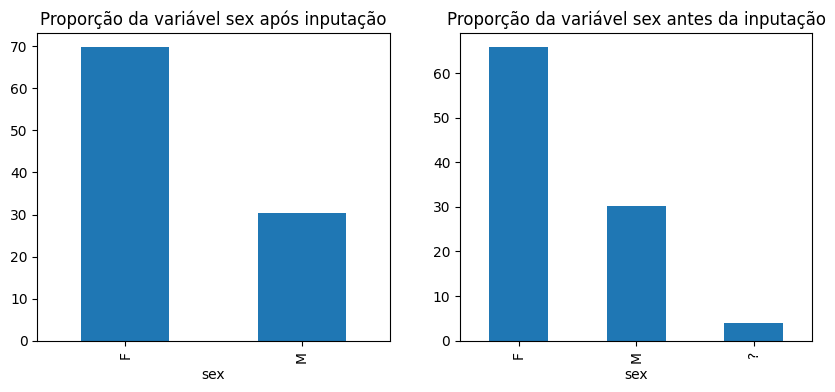

In [ ]:

# visualiza proporções

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

valores_sex__prenchidos.plot(kind='bar',
                             title='Proporção da variável sex após inputação',
                             ax=axes[0],
                             )
valores_sex__vazios.plot(kind='bar',
                         title='Proporção da variável sex antes da inputação',
                         ax=axes[1],
                             )
plt.show()

### Conclusão de Sex

Distribuição original: F 65.75%, M 30.28%, `?` 3.98%. Leve desbalanceamento de gênero na base.

**Tratamento aplicado:** imputação dos nulos pela moda (F), elevando a proporção para F 69.72%, M 30.28%.

**Hipótese para camada 3:** homens apresentam taxa de diagnóstico positivo levemente maior que mulheres (94% vs 91%, verificado via crosstab no reconhecimento), reforçando a hipótese de que costumam procurar ajuda médica com sintomas mais avançados. A ser confirmado com mais profundidade na análise bivariada.

### Analise de 'on thyroxine'

In [ ]:


# contagem de valores
cont_onthyr = df_pretratado['on thyroxine'].value_counts()
perc_onthyr = df_pretratado['on thyroxine'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_onthyr}\n\nPercentual: \n{perc_onthyr}')


Contagem: 
on thyroxine
f    3308
t     464
Name: count, dtype: int64

Percentual: 
on thyroxine
f   87.70
t   12.30
Name: proportion, dtype: float64


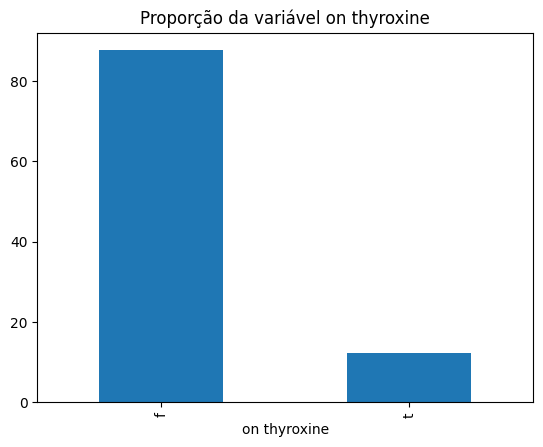

In [ ]:
# visualiza proporções

perc_onthyr.plot(kind='bar',
                 title='Proporção da variável on thyroxine'
                 )
plt.show()

### Conclusão de On Thyroxine

Variável binária indicando se o paciente está em tratamento com tiroxina. Distribuição: 87.7% não estão em tratamento (`f`) e 12.3% estão (`t`).

**Hipótese para camada 3:** pacientes em tratamento com tiroxina são mais propensos a diagnóstico positivo. Nota: tiroxina trata hipotireoidismo, não hipertireoidismo. A confirmação na camada 3 (98% positivo) levanta suspeita de leakage, não valida a lógica clínica original.

**Risco identificado:** se a taxa de positivo ou negativo dentro de `t` for muito alta, a variável pode funcionar como proxy do target, gerando data leakage. A ser verificado na análise bivariada.
- confirmar relação com (t) e `tsh` alto, para indicar doença Hipotireoidismo.
- corfirmar relação de (f) e `t4` alto, para indicar doença Hipotireoidismo.

### Análise de query on thyroxine

In [ ]:
# contagem de valores
cont_queryt = df_pretratado['query on thyroxine'].value_counts()
perc_queryt = df_pretratado['query on thyroxine'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_queryt}\n\nPercentual: \n{perc_queryt}')

Contagem: 
query on thyroxine
f    3722
t      50
Name: count, dtype: int64

Percentual: 
query on thyroxine
f   98.67
t    1.33
Name: proportion, dtype: float64


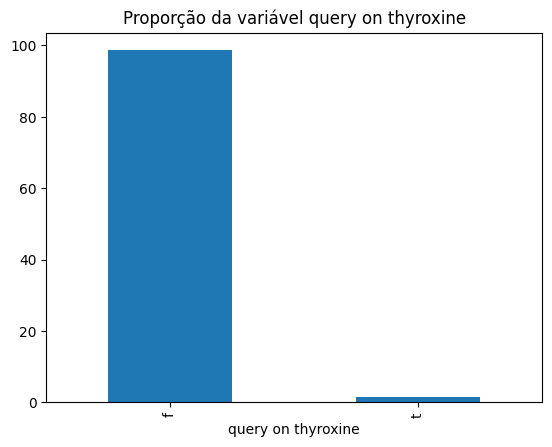

In [ ]:
# visualiza proporções

perc_queryt.plot(kind='bar',
                 title='Proporção da variável query on thyroxine'
                 )
plt.show()

### Conclusão de Query on Thyroxine

Alto desbalanceamento: 98.67% dos pacientes não questionaram sobre tratamento com tiroxina (`f`), apenas 1.33% (`t`).

**Pendência para próximas camadas:**
- Verificar relação com o target (camada 3) para avaliar poder preditivo
- Verificar redundância com `on thyroxine` (camada 4) antes de decidir entre manter, agrupar ou dropar a variável


### on antithyroid medication

In [ ]:
# contagem de valores
cont_antimed = df_pretratado['on antithyroid medication'].value_counts()
perc_antmed = df_pretratado['on antithyroid medication'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_antimed}\n\nPercentual: \n{perc_antmed}')

Contagem: 
on antithyroid medication
f    3729
t      43
Name: count, dtype: int64

Percentual: 
on antithyroid medication
f   98.86
t    1.14
Name: proportion, dtype: float64


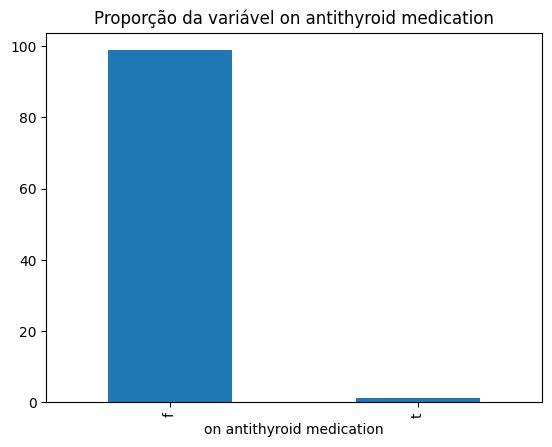

In [ ]:
# visualiza proporções

perc_antmed.plot(kind='bar',
                 title='Proporção da variável on antithyroid medication'
                 )
plt.show()

### Conclusão de On Antithyroid Medication

Alto desbalanceamento: 98.86% dos pacientes não estão em tratamento antitireoidiano (`f`), apenas 1.14% (`t`).

**Hipótese para camada 3:** pacientes com `t` devem apresentar TSH baixo e T4 alto, pois o medicamento antitireoidiano é indicado para hipertireoidismo. Isso contribui para resolver a questão em aberto sobre hipo vs hipertireoidismo no dataset.

**Pendência:** verificar relação com o target (camada 3) para avaliar poder preditivo, visto que a categoria `t` é rara (1.14%).


### Análise de sick

In [ ]:
# contagem de valores
cont_sick = df_pretratado['sick'].value_counts()
perc_sick = df_pretratado['sick'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_sick}\n\nPercentual: \n{perc_sick}')

Contagem: 
sick
f    3625
t     147
Name: count, dtype: int64

Percentual: 
sick
f   96.10
t    3.90
Name: proportion, dtype: float64


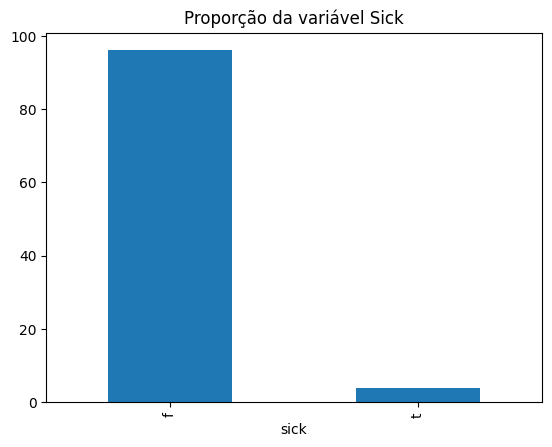

In [ ]:
# visualiza proporções

perc_sick.plot(kind='bar',
                 title='Proporção da variável Sick'
                 )
plt.show()

### Conclusão de Sick

sick = (t) é categoria rara apresentando 3.9%, e indica pessoa que estejam doentes

**Hipótese para camada 3:** sick = (t) terá disfunções nos exames mesmo sendo negativo  
**Risco identificado:** sick = (t) pode gerar apreendizado que certos valores de TSH/T4 indicam positivo, mas na verdade esses valores estão distorcidos pela doença concomitante, não pela disfunção tireoidiana.

### Análise de pregnant

In [ ]:
# contagem de valores
cont_pregnant = df_pretratado['pregnant'].value_counts()
perc_pregnant = df_pretratado['pregnant'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_pregnant}\n\nPercentual: \n{perc_pregnant}')

Contagem: 
pregnant
f    3719
t      53
Name: count, dtype: int64

Percentual: 
pregnant
f   98.59
t    1.41
Name: proportion, dtype: float64


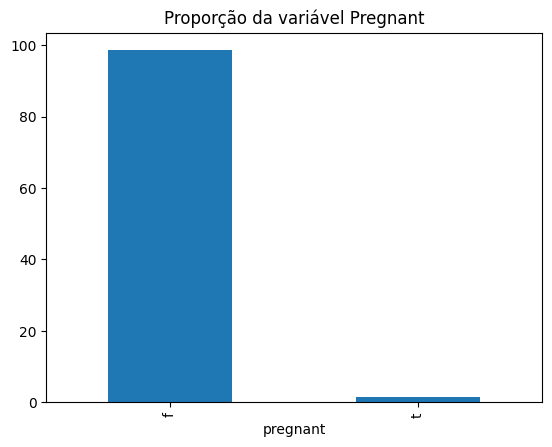

In [ ]:
# visualiza proporções

perc_pregnant.plot(kind='bar',
                 title='Proporção da variável Pregnant'
                 )
plt.show()

### Conclusão de Pregnant

Alto desbalanceamento: 98.59% não grávidas (`f`), apenas 1.41% grávidas (`t`).

**Hipótese para camada 3:** pacientes grávidas podem apresentar disfunção hormonal com TSH mais baixo e índices elevados de T3 e T4, simulando quadro de hipertireoidismo nos exames. Isso pode gerar falsos positivos no modelo.

**Pendência:** verificar relação com o target (camada 3) para avaliar poder preditivo, visto que a categoria `t` é rara (1.41%).

### Análise de thyroid surgery

In [ ]:
# contagem de valores
cont_surgery = df_pretratado['thyroid surgery'].value_counts()
perc_surgery = df_pretratado['thyroid surgery'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_surgery}\n\nPercentual: \n{perc_surgery}')

Contagem: 
thyroid surgery
f    3719
t      53
Name: count, dtype: int64

Percentual: 
thyroid surgery
f   98.59
t    1.41
Name: proportion, dtype: float64


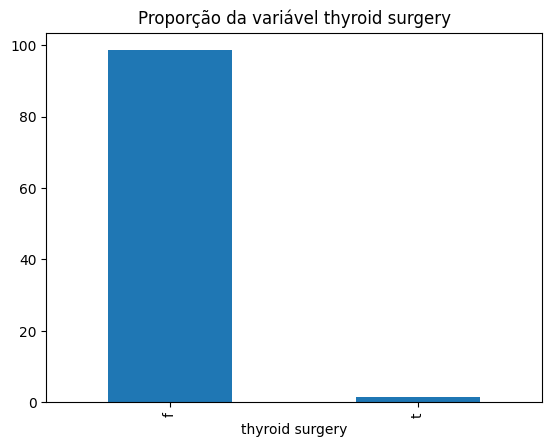

In [ ]:
# visualiza proporções

perc_surgery.plot(kind='bar',
                 title='Proporção da variável thyroid surgery'
                 )
plt.show()

### Conclusão de Thyroid Surgery

Alto desbalanceamento: 98.59% sem histórico de cirurgia na tireoide (`f`), apenas 1.41% com histórico (`t`).

**Hipótese para camada 3:** pacientes com histórico de cirurgia na tireoide podem apresentar disfunções nos exames e simular outras condições, afetando o poder preditivo da variável.

**Pendência:** verificar relação com o target (camada 3) para avaliar poder preditivo. Verificar na camada 4 se há cruzamento com `pregnant`, dado que os volumes são idênticos.

### Análise de I131 treatment

In [ ]:
# contagem de valores
cont_i131 = df_pretratado['I131 treatment'].value_counts()
perc_i131 = df_pretratado['I131 treatment'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_i131}\n\nPercentual: \n{perc_i131}')

Contagem: 
I131 treatment
f    3713
t      59
Name: count, dtype: int64

Percentual: 
I131 treatment
f   98.44
t    1.56
Name: proportion, dtype: float64


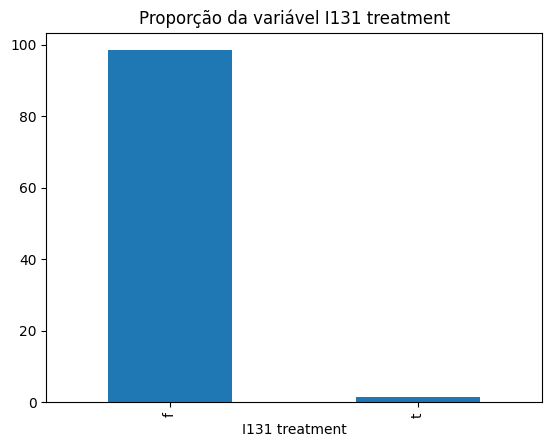

In [ ]:
# visualiza proporções

perc_i131.plot(kind='bar',
                 title='Proporção da variável I131 treatment'
                 )
plt.show()

### Conclusão de I131 Treatment

Alto desbalanceamento: 98.44% sem tratamento (`f`), apenas 1.56% com tratamento (`t`).

**Hipóteses para camada 3:**
- H1: pacientes com `t` foram positivos para hipertireoidismo ou tumor, visto que o I131 é indicado para essas condições
- H2: pacientes com `t` eram positivos para hipertireoidismo mas agora apresentam padrão de hipotireoidismo nos exames, podendo confundir o modelo

**Pendência:** verificar relação com o target e com os valores de TSH/T4 na camada 3 para confirmar qual hipótese se sustenta.

### Análise de query hypothyroid

In [ ]:
# contagem de valores
cont_qhypo = df_pretratado['query hypothyroid'].value_counts()
perc_qhypo = df_pretratado['query hypothyroid'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_qhypo}\n\nPercentual: \n{perc_qhypo}')

Contagem: 
query hypothyroid
f    3538
t     234
Name: count, dtype: int64

Percentual: 
query hypothyroid
f   93.80
t    6.20
Name: proportion, dtype: float64


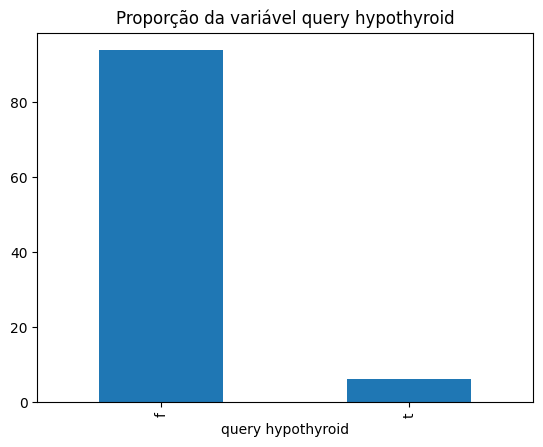

In [ ]:
# visualiza proporções

perc_qhypo.plot(kind='bar',
                 title='Proporção da variável query hypothyroid'
                 )
plt.show()

### Conclusão de Query Hypothyroid

Distribuição: 93.80% sem suspeita (`f`), 6.20% com suspeita de hipotireoidismo (`t`).

**Hipótese para camada 3:** pacientes com suspeita de hipotireoidismo (`t`) tendem a ser negativos no target, pois o padrão de exames do hipotireoidismo (TSH alto, T4 baixo) é oposto ao do hipertireoidismo, tornando improvável o diagnóstico positivo para hipertireoidismo.

**Pendência:** verificar taxa de positivo dentro de `t` na camada 3 para confirmar poder preditivo da variável.

### Análise de query hyperthyroid

In [ ]:
# contagem de valores
cont_qhyper = df_pretratado['query hyperthyroid'].value_counts()
perc_qhyper = df_pretratado['query hyperthyroid'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_qhyper}\n\nPercentual: \n{perc_qhyper}')

Contagem: 
query hyperthyroid
f    3535
t     237
Name: count, dtype: int64

Percentual: 
query hyperthyroid
f   93.72
t    6.28
Name: proportion, dtype: float64


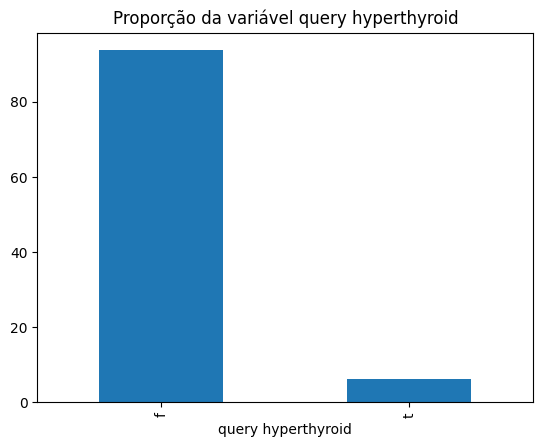

In [ ]:
# visualiza proporções

perc_qhyper.plot(kind='bar',
                 title='Proporção da variável query hyperthyroid'
                 )
plt.show()

### Conclusão de Query Hyperthyroid

Distribuição: 93.72% sem suspeita (`f`), 6.28% com suspeita de hipertireoidismo (`t`).

**Hipótese para camada 3:** pacientes com suspeita de hipertireoidismo (`t`) tendem a ser positivos no target, pois o padrão de exames do hipertireoidismo (TSH baixo, T4 alto) é alinhado com o diagnóstico positivo.

**Pendência:** verificar taxa de positivo dentro de `t` na camada 3 para confirmar poder preditivo. Verificar redundância com `query hypothyroid` na camada 4, visto que as distribuições são praticamente idênticas.

### Análise de lithium

In [ ]:
# contagem de valores
cont_lithium = df_pretratado['lithium'].value_counts()
perc_lithium = df_pretratado['lithium'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_lithium}\n\nPercentual: \n{perc_lithium}')

Contagem: 
lithium
f    3754
t      18
Name: count, dtype: int64

Percentual: 
lithium
f   99.52
t    0.48
Name: proportion, dtype: float64


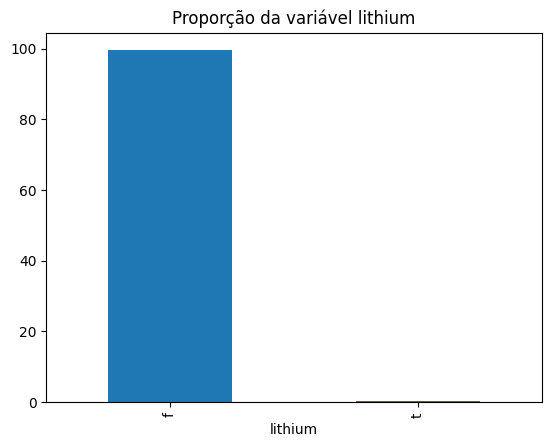

In [ ]:
# visualiza proporções

perc_lithium.plot(kind='bar',
                 title='Proporção da variável lithium'
                 )
plt.show()

### Conclusão de Lithium

Categoria extremamente rara: 99.52% sem uso de lítio (`f`), apenas 0.48% com uso (`t`), representando 18 pacientes.

**Hipótese para camada 3:** lítio pode interferir na função tireoidiana, ocasionando principalmente hipotireoidismo, mas com potencial de causar hipertireoidismo em alguns casos.

**Risco identificado:** volume de 18 pacientes em `t` é insuficiente para o modelo aprender padrão confiável. Alto risco de overfitting ou ruído.

**Pendência:** verificar poder preditivo na camada 3. Se baixo, dropar ou agrupar em "outros".

### Análise de goitre

In [ ]:
# contagem de valores
cont_goitre = df_pretratado['goitre'].value_counts()
perc_goitre = df_pretratado['goitre'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_goitre}\n\nPercentual: \n{perc_goitre}')

Contagem: 
goitre
f    3738
t      34
Name: count, dtype: int64

Percentual: 
goitre
f   99.10
t    0.90
Name: proportion, dtype: float64


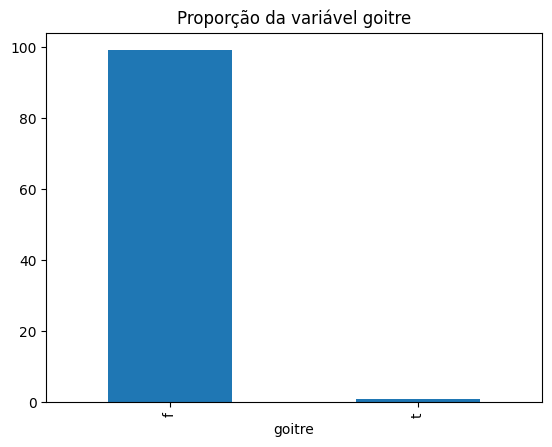

In [ ]:
# visualiza proporções

perc_goitre.plot(kind='bar',
                 title='Proporção da variável goitre'
                 )
plt.show()

### Conclusão de Goitre

Categoria extremamente rara: 0.9% apresentam a condição clinica do bócio ou goitre (`t`), representando 34 pacientes.

**Hipótese para camada 3:** goitre pode interferir na função tireoidiana, ocasionando disfunções hormonais aumentadas ou diminuidas

**Risco identificado:** volume de 34 pacientes em `t` é insuficiente para o modelo aprender padrão confiável. Alto risco de overfitting ou ruído.

**Pendência:** verificar poder preditivo na camada 3. Se baixo, dropar ou agrupar em "outros".

### Análise de tumor

In [ ]:
# contagem de valores
cont_tumor = df_pretratado['tumor'].value_counts()
perc_tumor = df_pretratado['tumor'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_tumor}\n\nPercentual: \n{perc_tumor}')

Contagem: 
tumor
f    3676
t      96
Name: count, dtype: int64

Percentual: 
tumor
f   97.45
t    2.55
Name: proportion, dtype: float64


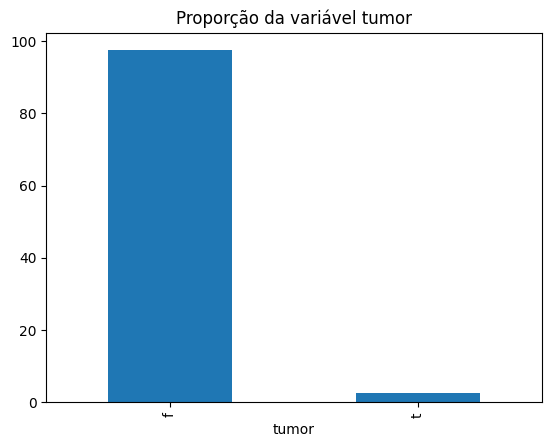

In [ ]:
# visualiza proporções

perc_tumor.plot(kind='bar',
                 title='Proporção da variável tumor'
                 )
plt.show()

### Conclusão de Tumor

Categoria rara: 97.45% sem tumor (`f`), 2.55% com tumor (`t`), representando 96 pacientes.

**Hipótese para camada 3:** tumor pode ou não interferir na produção hormonal da tireoide. Tumores funcionantes alteram TSH/T4, tumores não funcionantes podem não gerar alteração. A relação com o target é incerta e precisa ser verificada nos dados.

**Risco identificado:** variável com incerteza clínica alta pode gerar ruído no modelo se incluída sem validação de poder preditivo.

**Pendência:** verificar relação com o target e com os valores de TSH/T4 na camada 3 antes de decidir manter ou dropar.

### Análise de hypopituitary

In [ ]:
# contagem de valores
cont_hypopi = df_pretratado['hypopituitary'].value_counts()
perc_hypopi = df_pretratado['hypopituitary'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_hypopi}\n\nPercentual: \n{perc_hypopi}')

Contagem: 
hypopituitary
f    3771
t       1
Name: count, dtype: int64

Percentual: 
hypopituitary
f   99.97
t    0.03
Name: proportion, dtype: float64


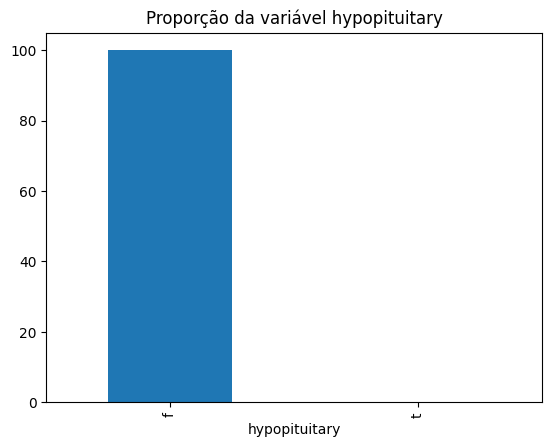

In [ ]:
# visualiza proporções

perc_hypopi.plot(kind='bar',
                 title='Proporção da variável hypopituitary'
                 )
plt.show()

### Conclusão de Hypopituitary

Categoria inviável: 99.97% sem hipopituitarismo (`f`), apenas 1 paciente com a condição (`t`).

**Decisão:** drop imediato. Volume de 1 paciente não gera nenhum padrão estatístico mensurável para o modelo.

**Nota clínica:** hipopituitarismo afeta a hipófise, órgão responsável pela produção de TSH, o que tornaria a variável clinicamente relevante. Porém o volume inviabiliza qualquer uso no modelo.

### Análise de psych

In [ ]:
# contagem de valores
cont_psych = df_pretratado['psych'].value_counts()
perc_psych = df_pretratado['psych'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_psych}\n\nPercentual: \n{perc_psych}')

Contagem: 
psych
f    3588
t     184
Name: count, dtype: int64

Percentual: 
psych
f   95.12
t    4.88
Name: proportion, dtype: float64


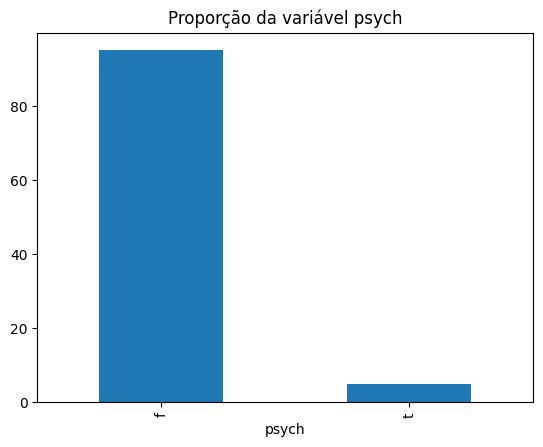

In [ ]:
# visualiza proporções

perc_psych.plot(kind='bar',
                 title='Proporção da variável psych'
                 )
plt.show()

### Conclusão de Psych

Distribuição: 95.12% sem condição psiquiátrica (`f`), 4.88% com condição (`t`).

**Hipótese para camada 3:** pacientes com condição psiquiátrica (`t`) têm relação indireta com o target, pois medicamentos utilizados no tratamento psiquiátrico, como lítio, podem interferir na função tireoidiana.

**Pendência:** verificar relação com o target na camada 3. Verificar redundância com `lithium` na camada 4, visto que pacientes psiquiátricos podem estar em uso de lítio.

### Analsie de  TSH Measured

In [ ]:
# contagem de valores
cont_tshm = df_pretratado['TSH measured'].value_counts()
perc_tshm = df_pretratado['TSH measured'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_tshm}\n\nPercentual: \n{perc_tshm}')

Contagem: 
TSH measured
t    3403
f     369
Name: count, dtype: int64

Percentual: 
TSH measured
t   90.22
f    9.78
Name: proportion, dtype: float64


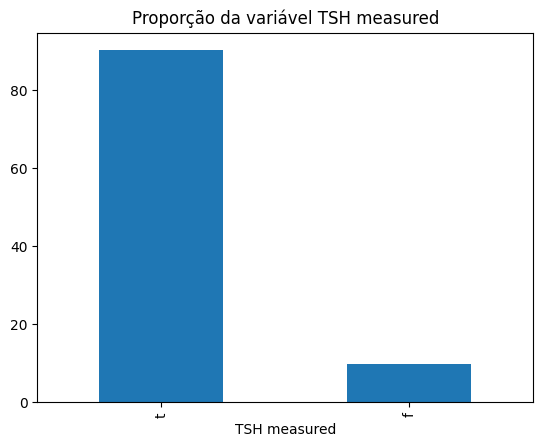

In [ ]:
# visualiza proporções

perc_tshm.plot(kind='bar',
                 title='Proporção da variável TSH measured'
                 )
plt.show()

### Conclusão de TSH Measured

Distribuição: 90.22% com exame realizado (`t`), 9.78% sem realização (`f`).

**Hipótese para camada 3:** pacientes com `TSH measured = f` tiveram algum fator clínico que pesou na decisão de não realizar o exame. A ausência do TSH pode ser informação relevante para o modelo.

**Pendência:** verificar relação com o target na camada 3. Analisar junto com a coluna `TSH` na camada 4, pois os nulos de `TSH` correspondem diretamente aos casos onde `TSH measured = f`.

### Análise TSH

In [ ]:
# visualização de possiveis outliers

fig = px.box(df_pretratado,
             y='TSH',
             title='Boxplot TSH',
             points='all',
             )
fig.show()

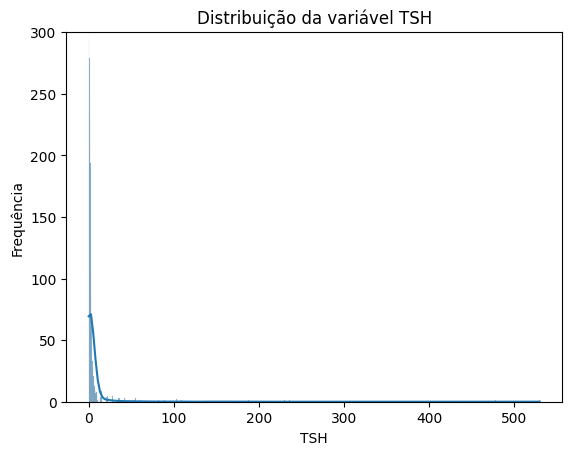

In [ ]:
# visualiza distribuição da variavel

sns.histplot(data=df_pretratado, x='TSH', kde=True)
plt.title('Distribuição da variável TSH')
plt.xlabel('TSH')
plt.ylabel('Frequência')
plt.ylim(0,300)

plt.show()

In [ ]:
# analise de simetria

df_pretratado['TSH'].skew()

np.float64(13.88265275504177)

### Conclusão de TSH

Distribuição com forte assimetria à direita (skewness = 13.88), massa concentrada entre 0 e 6, com outliers extremos chegando a 530. Mediana de 1.40, dentro da faixa normal (0.5 a 4.5), mas média de 5.09 distorcida pelos outliers.

**Nota clínica:** valores muito altos de TSH são clinicamente possíveis em hipotireoidismo grave não tratado, não necessariamente erros de coleta.

**Hipótese para camada 3:** a distribuição de TSH deve diferir significativamente entre classes positiva e negativa, sendo o principal marcador discriminante do dataset.

**Pendência para pré-processamento:** aplicar transformação `log1p` ou Box-Cox antes de modelos sensíveis a escala (regressão logística, SVM). XGBoost tolera a assimetria sem transformação.

### Análise de T3 Measuered

In [ ]:
# contagem de valores
cont_t3m = df_pretratado['T3 measured'].value_counts()
perc_t3m = df_pretratado['T3 measured'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_t3m}\n\nPercentual: \n{perc_t3m}')

Contagem: 
T3 measured
t    3003
f     769
Name: count, dtype: int64

Percentual: 
T3 measured
t   79.61
f   20.39
Name: proportion, dtype: float64


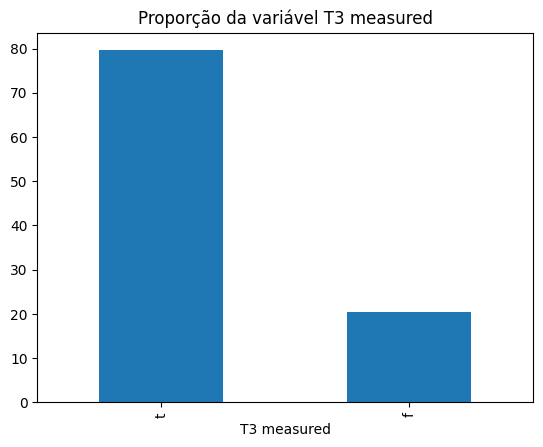

In [ ]:
# visualiza proporções

perc_t3m.plot(kind='bar',
                 title='Proporção da variável T3 measured'
                 )
plt.show()

### Conclusão de T3 Measured

Distribuição: 79.61% com exame realizado (`t`), 20.39% sem realização (`f`).

**Nota clínica:** T3 é solicitado em casos específicos, sendo menos prioritário que o TSH como exame de triagem. A não coleta indica que o médico considerou o TSH suficiente para a avaliação.

**Pendência:** os 20.39% sem coleta correspondem aos nulos em `T3`. Verificar relação com o target na camada 3 e analisar junto com a coluna `T3` na camada 4.

In [ ]:
# visualização de possiveis outliers

fig = px.box(df_pretratado,
             y='T3',
             title='Boxplot T3',
             points='all',
             )
fig.show()

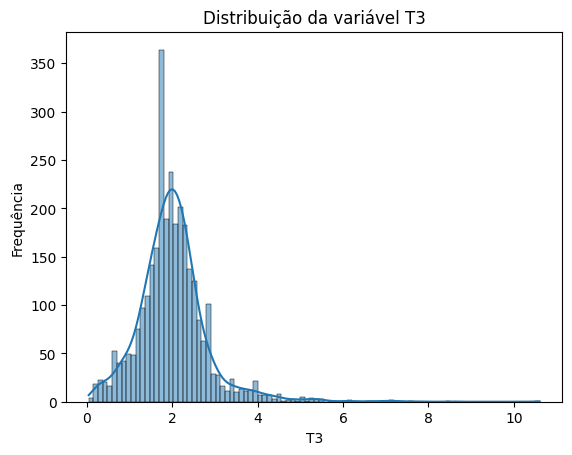

In [ ]:
# visualiza distribuição da variavel

sns.histplot(data=df_pretratado, x='T3', kde=True)
plt.title('Distribuição da variável T3')
plt.xlabel('T3')
plt.ylabel('Frequência')

plt.show()

In [ ]:
# analise de simetria

df_pretratado['T3'].skew()

np.float64(1.7308739623616052)

### Conclusão de T3

Distribuição com assimetria à direita moderada (skewness = 1.73), pico em torno de 2.0, com outliers acima de 6. Mediana de 2.0, abaixo da faixa normal de referência (2.5 a 4.0).

**Nota clínica:** mediana abaixo do valor de referência sugere que a base tem concentração de pacientes com T3 baixo, o que pode indicar predominância de hipotireoidismo na amostra.

**Hipótese para camada 3:** a distribuição de T3 deve diferir entre classes positiva e negativa, com positivos apresentando valores mais elevados se o dataset for de hipertireoidismo.

**Pendência para pré-processamento:** avaliar transformação `log1p` para modelos sensíveis a escala.

### Análise TT4 Mesured

In [ ]:
# contagem de valores
cont_tt4m = df_pretratado['TT4 measured'].value_counts()
perc_tt4m = df_pretratado['TT4 measured'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_tt4m}\n\nPercentual: \n{perc_tt4m}')

Contagem: 
TT4 measured
t    3541
f     231
Name: count, dtype: int64

Percentual: 
TT4 measured
t   93.88
f    6.12
Name: proportion, dtype: float64


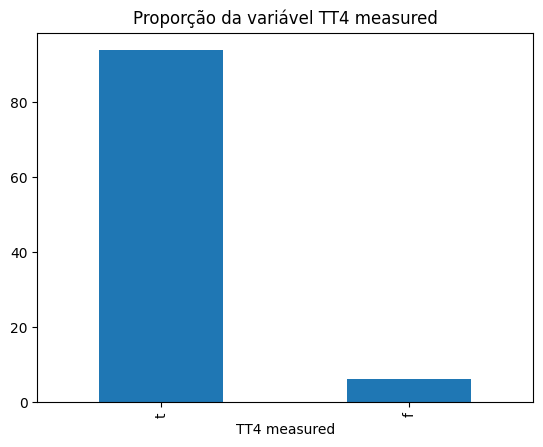

In [ ]:
# visualiza proporções

perc_tt4m.plot(kind='bar',
                 title='Proporção da variável TT4 measured'
                 )
plt.show()

### Conclusão de TT4 Measured

Distribuição: 93.88% com exame realizado (`t`), 6.12% sem realização (`f`).

**Nota clínica:** TT4 é exame confirmatório, solicitado após triagem com TSH. A não coleta indica que o médico considerou o TSH suficiente para avaliação, sem necessidade de confirmação adicional.

**Pendência:** os 6.12% sem coleta correspondem aos nulos em `TT4`. Verificar relação com o target na camada 3 e analisar junto com a coluna `TT4` na camada 4.

### Análise de TT4

In [ ]:
# visualização de possiveis outliers

fig = px.box(df_pretratado,
             y='TT4',
             title='Boxplot TT4',
             points='all',
             )
fig.show()

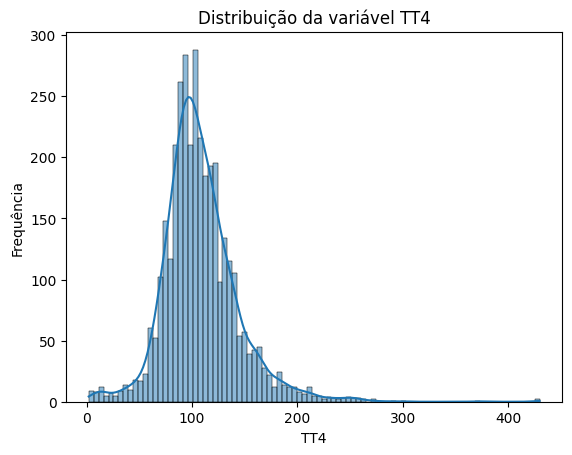

In [ ]:
# visualiza distribuição da variavel

sns.histplot(data=df_pretratado, x='TT4', kde=True)
plt.title('Distribuição da variável TT4')
plt.xlabel('TT4')
plt.ylabel('Frequência')

plt.show()

In [ ]:
# analise de simetria

df_pretratado['TT4'].skew()

np.float64(1.26770404513532)

### Conclusão de TT4

Distribuição com assimetria moderada à direita (skewness = 1.27). Média de 108.32 e mediana de 103 nmol/L, dentro da faixa de referência normal (60-150 nmol/L). Maior parte dos dados agrupada dentro da distribuição padrão, com cauda acentuada à direita.

**Risco identificado:** outliers moderados e severos presentes, mas clinicamente plausíveis em quadros de hipertireoidismo severo.

**Hipótese para camada 3:** pacientes positivos no target apresentam valores elevados de TT4.

**Pendências:** validar relação com o target na camada 3. Verificar os 6.12% sem coleta junto com `TT4 measured` e definir tratamento dos valores nulos no pré-processamento.

### Análise de T4U Measured

In [ ]:
# contagem de valores
cont_t4um = df_pretratado['T4U measured'].value_counts()
perc_t4um = df_pretratado['T4U measured'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_t4um}\n\nPercentual: \n{perc_t4um}')

Contagem: 
T4U measured
t    3385
f     387
Name: count, dtype: int64

Percentual: 
T4U measured
t   89.74
f   10.26
Name: proportion, dtype: float64


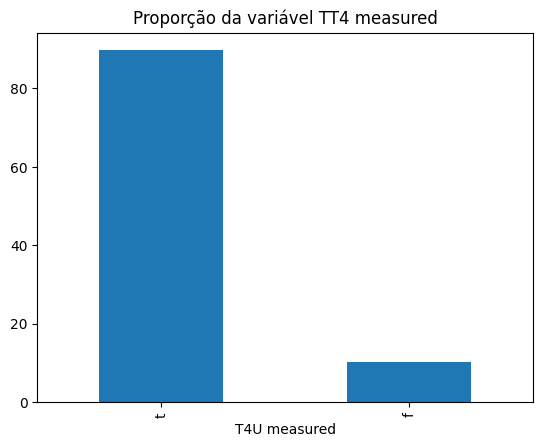

In [ ]:
# visualiza proporções

perc_t4um.plot(kind='bar',
                 title='Proporção da variável TT4 measured'
                 )
plt.show()

### Conclusão de T4U Measured

Distribuição: 89.74% com exame realizado (`t`), 10.26% sem realização (`f`).

**Nota clínica:** T4U mede a capacidade de transporte dos hormônios tireoidianos pelas proteínas. É solicitado em situações específicas como gravidez, uso de medicamentos ou doenças que alteram as proteínas carreadoras, sendo menos prioritário que TSH e TT4 na triagem padrão.

**Pendência:** os 10.26% sem coleta correspondem aos nulos em `T4U`. Verificar relação com o target na camada 3 e analisar junto com a coluna `T4U` na camada 4.

### Análise de T4U

In [ ]:
  # visualização de possiveis outliers

fig = px.box(df_pretratado,
             y='T4U',
             title='Boxplot T4U',
             points='all',
             )
fig.show()

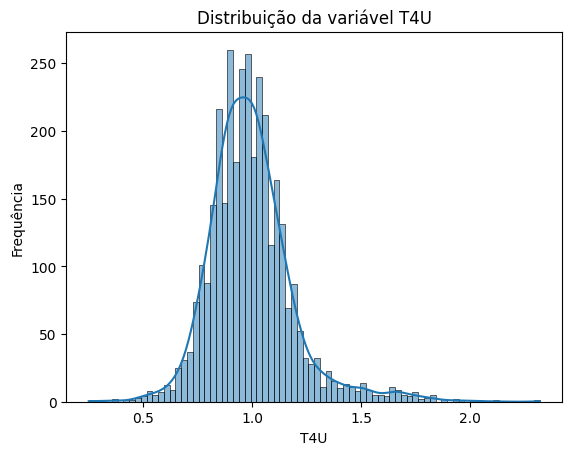

In [ ]:
# visualiza distribuição da variavel

sns.histplot(data=df_pretratado, x='T4U', kde=True)
plt.title('Distribuição da variável T4U')
plt.xlabel('T4U')
plt.ylabel('Frequência')

plt.show()

In [ ]:
# analise de simetria

df_pretratado['T4U'].skew()

np.float64(1.2326742385072795)

### Conclusão de T4U

Distribuição aproximadamente normal com leve assimetria à direita (skewness = 1.23). Média de 0.99 e mediana de 0.98, com outliers acima e abaixo das fences.

**Nota clínica:** exame considerado obsoleto, substituído pelo TT4 na maioria dos casos. Ainda utilizado em situações específicas como gravidez ou uso de medicamentos que estimulam hormônios como anticoncepcionais.

**Hipótese para camada 3:** pacientes positivos para hipertireoidismo devem apresentar T4U mais baixo, pois as proteínas carreadoras ficam saturadas pelo excesso de hormônios circulantes.

**Pendência:** verificar relevância com o target na camada 3. Verificar redundância com `TT4` e `FTI` na camada 4, pois FTI é calculado a partir de TT4 e T4U.

### Análise de FTI Measured

In [ ]:
# contagem de valores
cont_ftim = df_pretratado['FTI measured'].value_counts()
perc_ftim = df_pretratado['FTI measured'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_ftim}\n\nPercentual: \n{perc_ftim}')

Contagem: 
FTI measured
t    3387
f     385
Name: count, dtype: int64

Percentual: 
FTI measured
t   89.79
f   10.21
Name: proportion, dtype: float64


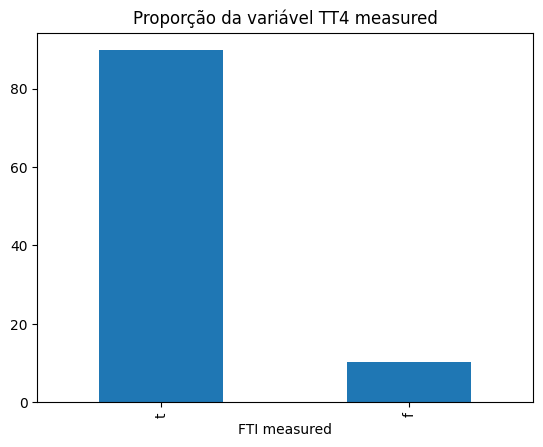

In [ ]:
# visualiza proporções

perc_ftim.plot(kind='bar',
                 title='Proporção da variável TT4 measured'
                 )
plt.show()

### Conclusão de FTI Measured

Distribuição: 89.79% com exame realizado (`t`), 10.21% sem realização (`f`).

**Nota clínica:** FTI é um índice calculado matematicamente a partir de TT4 e T4U, estimando a quantidade de hormônios ativos no organismo. Não é um exame direto.

**Pendência:** os 10.21% sem coleta correspondem aos nulos em `FTI`. Verificar relação com o target na camada 3. Verificar multicolinearidade com `TT4` e `T4U` na camada 4, pois FTI é derivado dessas duas variáveis.

### Análise de FTI

In [ ]:
# visualização de possiveis outliers

fig = px.box(df_pretratado,
             y='FTI',
             title='Boxplot FTI',
             points='all',
             )
fig.show()

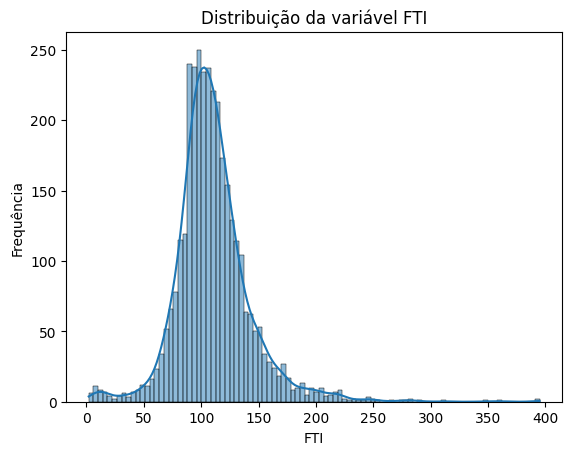

In [ ]:
# visualiza distribuição da variavel

sns.histplot(data=df_pretratado, x='FTI', kde=True)
plt.title('Distribuição da variável FTI')
plt.xlabel('FTI')
plt.ylabel('Frequência')

plt.show()

In [ ]:
# analise de simetria

df_pretratado['FTI'].skew()

np.float64(1.3454318268817946)

### Conclusão de FTI

Distribuição com assimetria moderada à direita (skewness = 1.34). Média de 110 e mediana de 107, com outliers acima da upper fence (170) chegando a 395.

**Nota clínica:** FTI é índice calculado a partir de TT4 e T4U, estimando a quantidade de hormônios ativos no organismo. Distribuição similar ao TT4 é esperada dado que depende diretamente desse valor.

**Hipótese para camada 3:** pacientes positivos devem apresentar FTI elevado, refletindo excesso de hormônios ativos em quadro de hipertireoidismo.

**Pendência:** verificar relevância com o target na camada 3. Verificar multicolinearidade com TT4 e T4U na camada 4, pois as três variáveis carregam informação sobreposta.

### Análise de referral source

In [ ]:
# contagem de valores
cont_ref = df_pretratado['referral source'].value_counts()
perc_ref = df_pretratado['referral source'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_ref}\n\nPercentual: \n{perc_ref}')

Contagem: 
referral source
other    2201
SVI      1034
SVHC      386
STMW      112
SVHD       39
Name: count, dtype: int64

Percentual: 
referral source
other   58.35
SVI     27.41
SVHC    10.23
STMW     2.97
SVHD     1.03
Name: proportion, dtype: float64


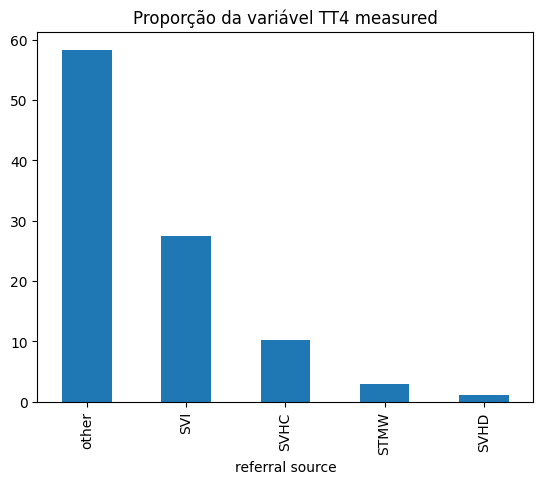

In [ ]:
# visualiza proporções

perc_ref.plot(kind='bar',
                 title='Proporção da variável TT4 measured'
                 )
plt.show()

### Conclusão de Referral Source

Distribuição: `other` 58.35%, `SVI` 27.41%, `SVHC` 10.23%, `STMW` 2.97%, `SVHD` 1.03%.

**Nota de negócio:** `other` agrupa fontes distintas (walk-in, clínica geral, não classificado) em uma única categoria, perdendo granularidade. Limitação do dataset sem informação adicional para desagregar.

**Hipótese para camada 3:** pacientes encaminhados de institutos especializados (`SVI`, `SVHC`) têm maior probabilidade de diagnóstico positivo, pois chegam com suspeita clínica direcionada.

**Pendência:** verificar taxa de positivo por categoria na camada 3. `SVHD` com 1.03% está no limiar de categoria rara, verificar se concentra 100% positivo ou negativo antes de decidir manter, agrupar ou dropar.

### Análise de binaryClass (target)

In [ ]:
# contagem de valores
cont_target = df_pretratado['binaryClass'].value_counts()
perc_target = df_pretratado['binaryClass'].value_counts(normalize=True)*100
print(f'Contagem: \n{cont_target}\n\nPercentual: \n{perc_target}')

Contagem: 
binaryClass
P    3481
N     291
Name: count, dtype: int64

Percentual: 
binaryClass
P   92.29
N    7.71
Name: proportion, dtype: float64


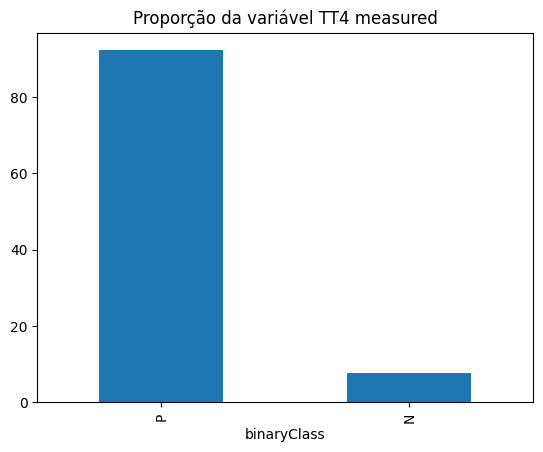

In [ ]:
# visualiza proporções

perc_target.plot(kind='bar',
                 title='Proporção da variável TT4 measured'
                 )
plt.show()

### Conclusão de BinaryClass (Target)

Desbalanceamento severo: 92.29% positivo (`P`), 7.71% negativo (`N`).

**Risco identificado:** modelo pode aprender a prever sempre `P` e ainda assim acertar 92% dos casos, mas falhando exatamente nos casos negativos que importam.

**Decisão pendente para modelagem:** avaliar entre SMOTE e `class_weight`. SMOTE cria amostras sintéticas com risco de padrões artificiais, especialmente crítico em dados médicos. `class_weight` é mais conservador, penalizando erros na classe minoritária sem alterar os dados.

**Métrica:** acurácia não é adequada para esse desbalanceamento. Priorizar F1-score, Recall da classe negativa e AUC-ROC.

## Síntese da Camada 2 - Análise Univariada

### Variáveis Numéricas

| Variável | Mediana | Skewness | Observação |
|----------|---------|----------|------------|
| age | 54 | -0.21 | Distribuição aproximadamente normal, concentração em adultos de meia-idade |
| TSH | 1.40 | 13.88 | Assimetria severa, transformação log necessária |
| T3 | 2.00 | 1.73 | Assimetria moderada, abaixo da faixa normal |
| TT4 | 103 | 1.27 | Distribuição normal, valores dentro da referência |
| T4U | 0.98 | 1.23 | Distribuição normal, exame obsoleto |
| FTI | 107 | 1.34 | Distribuição similar ao TT4, multicolinearidade esperada |

### Principais Achados

- Desbalanceamento severo no target: 92.29% positivo vs 7.71% negativo
- TSH requer transformação logarítmica antes da modelagem
- Múltiplas variáveis com categoria rara abaixo de 1%: `lithium`, `goitre`, `hypopituitary`
- `hypopituitary` com 1 único paciente positivo: drop recomendado
- FTI, TT4 e T4U com potencial multicolinearidade a verificar na camada 4

### Pendências para Próximas Camadas

- Camada 3: verificar poder preditivo de todas as variáveis com categoria rara
- Camada 3: cruzar TSH e TT4 com binaryClass para resolver a questão hipo vs hiper
- Camada 4: verificar redundância entre FTI, TT4 e T4U
- Camada 4: verificar redundância entre `psych` e `lithium`
- Pré-processamento: definir tratamento dos nulos informativos nas colunas de exame

## Hipóteses Levantadas - Camada 2

### Variáveis Demográficas
- **age:** doença mais prevalente em adultos de meia-idade para mais velhos. `[Camada 3]`
- **sex:** homens procuram ajuda médica com sintomas mais avançados, sendo mais propensos a diagnóstico positivo. `[Camada 3]`

### Variáveis de Tratamento
- **on thyroxine:** pacientes em tratamento com tiroxina são mais propensos a diagnóstico positivo. Nota: tiroxina trata hipotireoidismo, não hipertireoidismo. A confirmação na camada 3 (98% positivo) levanta suspeita de leakage, não valida a lógica clínica original.
- **on antithyroid medication:** pacientes em tratamento antitireoidiano (`t`) serão positivos no binaryClass, pois o medicamento é indicado para hipertireoidismo. `[Camada 3]`
- **I131 treatment:** H1: pacientes com `t` foram positivos para hipertireoidismo ou tumor. H2: pacientes com `t` eram positivos para hipertireoidismo mas agora apresentam padrão de hipotireoidismo nos exames. `[Camada 3]`

### Variáveis Clínicas
- **sick:** pacientes com condição clínica concomitante podem apresentar disfunções nos exames mesmo sendo negativos no target. `[Camada 4]`
- **pregnant:** pacientes grávidas podem apresentar TSH mais baixo e T3/T4 elevados, simulando quadro de hipertireoidismo nos exames. `[Camada 3 e 4]`
- **thyroid surgery:** pacientes com histórico de cirurgia podem apresentar disfunções nos exames e simular outras condições. `[Camada 4]`
- **psych:** pacientes com condição psiquiátrica têm relação indireta com o target via medicamentos que interferem na tireoide. `[Camada 3 e 4]`

### Variáveis de Suspeita Clínica
- **query hypothyroid:** pacientes com suspeita de hipotireoidismo tendem a ser negativos no target. `[Camada 3]`
- **query hyperthyroid:** pacientes com suspeita de hipertireoidismo tendem a ser positivos no target. `[Camada 3]`

### Variáveis de Exame
- **TSH:** principal marcador discriminante, distribuição deve diferir significativamente entre classes. `[Camada 3]`
- **T3:** positivos devem apresentar valores mais elevados se o dataset for de hipertireoidismo. `[Camada 3]`
- **TT4:** pacientes positivos devem apresentar valores elevados de TT4. `[Camada 3]`
- **T4U:** pacientes positivos devem apresentar T4U mais baixo, pois proteínas carreadoras ficam saturadas no hipertireoidismo. `[Camada 3 e 4]`
- **FTI:** pacientes positivos devem apresentar FTI elevado, refletindo excesso de hormônios ativos. `[Camada 3]`
- **FTI x TT4 x T4U:** multicolinearidade esperada, FTI pode substituir as duas. `[Camada 4]`

### Questão em Aberto
- Dataset representa hipo ou hipertireoidismo? A ser resolvida cruzando TSH com binaryClass na camada 3. `[Camada 3]`

## Camada 3 - O que explica o que prevejo?
variáveis tem poder preditivo real ou é ruído?   
 - Numérica vs target: a distribuição muda entre classes?   
 - Categórica vs target: taxa de evento por categoria   
 - Formar hipóteses antes de calcular correlações  

### Age x Bynarry class

In [ ]:
# recorte dos grupos de idades
faixas_age = pd.cut(df_pretratado['age'], bins=[0,10,20,30,40,50,60,70,80,90,100], labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100'])
# contagem por faixa de idade
faixas_age.value_counts().sort_index()

,count
age,
0-10,22
10-20,181
20-30,455
30-40,529
40-50,492
50-60,700
60-70,695
70-80,541
80-90,149


In [ ]:
# visualiza distribuição da variavel age com
pd.crosstab(faixas_age, df_pretratado['binaryClass'], normalize='index')

binaryClass,N,P
age,,
0-10,0.32,0.68
10-20,0.07,0.93
20-30,0.06,0.94
30-40,0.08,0.92
40-50,0.08,0.92
50-60,0.08,0.92
60-70,0.09,0.91
70-80,0.07,0.93
80-90,0.07,0.93


In [ ]:
# visualização da distribuição de binaryClassa por age

df_age = pd.DataFrame({
    'Faixa': faixas_age,
    'binaryClass': df_pretratado['binaryClass']
})
df_age['Faixa'].value_counts().sort_index()

ordem_faixas = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100"]
display(df_age)



,Faixa,binaryClass
0,40-50,P
1,20-30,P
2,40-50,P
3,60-70,P
4,60-70,P
...,...,...
3767,20-30,P
3768,60-70,P
3769,70-80,P
3770,70-80,P


In [ ]:
df_age.groupby('Faixa')['binaryClass'].value_counts().unstack()

/tmp/ipykernel_60029/673153847.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



binaryClass,N,P
Faixa,,
0-10,7,15
10-20,13,168
20-30,28,427
30-40,40,489
40-50,39,453
50-60,55,645
60-70,61,634
70-80,38,503
80-90,10,139


In [ ]:
# visualiza boxplot de age por binaryclass, para comparação de potncial preditivo das classes

fig = px.box(df_pretratado,
             x='binaryClass',
             y='age')
fig.show()

In [ ]:
# visualiza distribuição das idades

fig = px.histogram(df_age,
                   x='Faixa',
                   color='binaryClass',
                   barmode='group',
                   nbins=10,
                   title='Distribuição de Idades',
                   category_orders={'Faixa': ordem_faixas}
                  )

fig.show()

### Age x BinaryClass (Camada 3)

Distribuições de idade entre positivos e negativos são praticamente idênticas: mediana P=54, N=55, IQR de P (36-67) e N (37-65) com sobreposição quase total.

**Hipótese testada** doença mais prevalente em adultos de meia-idade para mais velhos **confirmada**,

**Conclusão:** age tem baixo poder preditivo isolado. A distribuição não separa as classes de forma relevante.

**Decisão para modelagem:** manter como feature de suporte, pois pode contribuir em combinação com outras variáveis, mas não como preditor principal.

### Analise de Sex X BynaryClass

In [ ]:
# df para visualização de contagem
df_sex = df_pretratado.groupby(['sex', 'binaryClass']).size().reset_index(name='count')
# visualizagerais de sex separado por binaryclass
fig = px.bar(df_sex,
             x='sex',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção para testar a hipotese levantada

df_sex['proporcao'] = df_sex['count'] / df_sex.groupby('sex')['count'].transform('sum')
display(df_sex)

,sex,binaryClass,count,proporcao
0,F,N,226,0.09
1,F,P,2404,0.91
2,M,N,65,0.06
3,M,P,1077,0.94


### Sex x BinaryClass (Camada 3)

Proporção de positivos: F = 91%, M = 94%. Diferenca de 3 pontos percentuais entre os generosm, confirma a hipótese de homens propcuram ajuda mais tardiamente o que causa mais positivos

**hipótese**: homens procuram ajuda médica com sintomas mais avançados, sendo mais propensos a diagnóstico positivo **confirmada**

**Conclusao:** sex tem baixo poder preditivo isolado. A diferenca existe mas e pequena e pode refletir o desbalanceamento geral da base.

**Decisao para modelagem:** manter como feature de suporte. Pode contribuir em combinacao com outras variaveis, especialmente em modelos que capturam interacoes entre features.

### Analise on thyroxine x BinaryClass

In [ ]:
# df para visualização de contagem
df_tiroxina = df_pretratado.groupby(['on thyroxine', 'binaryClass']).size().reset_index(name='count')
# visualizagerais de on thyroxine separado por binaryclass
fig = px.bar(df_tiroxina,
             x='on thyroxine',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção para testar a hipotese levantada

df_tiroxina['proporcao'] = df_tiroxina['count'] / df_tiroxina.groupby('on thyroxine')['count'].transform('sum')
display(df_tiroxina)

,on thyroxine,binaryClass,count,proporcao
0,f,N,282,0.09
1,f,P,3026,0.91
2,t,N,9,0.02
3,t,P,455,0.98


### On Thyroxine x BinaryClass (Camada 3)

Proporção de positivos: `f` = 91%, `t` = 98%. Diferença de 7 pontos percentuais.

**Hipótese:** pacientes em tratamento com tiroxina são mais propensos a diagnóstico positivo, pois o tratamento é indicado após detecção de disfunção tireoidiana (hipotireoidismo) **Confirmada**.

**Risco identificado:** 98% de positivos em `t` levanta suspeita de data leakage. O modelo pode aprender "toma tiroxina = positivo" ao invés dos padrões clínicos reais.

**Decisão postergada:** tiroxina é indicada para hipotireoidismo, não hipertireoidismo. Verificar na camada 4 a relação com os hormônios TSH/T4 antes de decidir entre manter ou dropar a variável.

### Analise query on thyroxine x bynaryclass

In [ ]:
# df para visualização de contagem
df_q_tiroxina = df_pretratado.groupby(['query on thyroxine', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de query on thyroxine separado por binaryclass
fig = px.bar(df_q_tiroxina,
             x='query on thyroxine',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção para testar a hipotese levantada

df_q_tiroxina['proporcao'] = df_q_tiroxina['count'] / df_q_tiroxina.groupby('query on thyroxine')['count'].transform('sum')
display(df_q_tiroxina)

,query on thyroxine,binaryClass,count,proporcao
0,f,N,288,0.08
1,f,P,3434,0.92
2,t,N,3,0.06
3,t,P,47,0.94


### Query on Thyroxine x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 94%. Diferença de apenas 2 pontos percentuais com volume de 50 pacientes em `t`.

**Conclusão:** baixo poder preditivo. A diferença de 2 pontos percentuais com volume tão pequeno pode ser variação aleatória, não padrão real.

**Decisão:** dropar do modelo. Categoria rara com poder preditivo insuficiente traz mais ruído do que capacidade preditiva.

### Analise on antithyroid medication x binaryClass

In [ ]:
# df para visualização de contagem
df_tmedication = df_pretratado.groupby(['on antithyroid medication', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de on antithyroid medication separado por binaryclass
fig = px.bar(df_tmedication,
             x='on antithyroid medication',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção para testar a hipotese levantada

df_tmedication['proporcao'] = df_tmedication['count'] / df_tmedication.groupby('on antithyroid medication')['count'].transform('sum')
display(df_tmedication)

,on antithyroid medication,binaryClass,count,proporcao
0,f,N,290,0.08
1,f,P,3439,0.92
2,t,N,1,0.02
3,t,P,42,0.98


### On Antithyroid Medication x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 98%. Diferença de 6 pontos percentuais com volume de 43 pacientes em `t`.

**Hipótese:** pacientes em tratamento antitireoidiano têm alta taxa de diagnóstico positivo, clinicamente coerente pois o medicamento é indicado para hipertireoidismo. **confirmado**

**Distinção de leakage:** diferente de `on thyroxine`, a correlação aqui é clinicamente verdadeira. Antitireoidiano = hipertireoidismo é uma relação real, não vazamento de informação falsa.

**Decisão:** manter como feature de suporte. Não é preditor principal pois em produção pacientes novos podem não estar em tratamento ainda, mas contribui como sinal complementar.

### Análise de Sick X BinaryClass

In [ ]:
# df para visualização de contagem
df_sick = df_pretratado.groupby(['sick', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de sick separado por binaryclass
fig = px.bar(df_sick,
             x='sick',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção para testar a hipotese levantada

df_sick['proporcao'] = df_sick['count'] / df_sick.groupby('sick')['count'].transform('sum')
display(df_sick)

,sick,binaryClass,count,proporcao
0,f,N,280,0.08
1,f,P,3345,0.92
2,t,N,11,0.07
3,t,P,136,0.93


### Sick x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 93%. Diferença de apenas 1 ponto percentual.

**Conclusão:** baixo poder preditivo direto com o target.

**Pendência camada 4:** verificar se `sick = t` interfere nos valores dos exames (TSH, T3, TT4)

### Analise pregnant x BinaryClass

In [ ]:
# df para visualização de contagem
df_pregnant = df_pretratado.groupby(['pregnant', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de pregnant separado por binaryclass
fig = px.bar(df_pregnant,
             x='pregnant',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção para testar a hipotese levantada

df_pregnant['proporcao'] = df_pregnant['count'] / df_pregnant.groupby('pregnant')['count'].transform('sum')
display(df_pregnant)

,pregnant,binaryClass,count,proporcao
0,f,N,291,0.08
1,f,P,3428,0.92
2,t,P,53,1.00


### Pregnant x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 100%. Nenhum caso negativo em pacientes grávidas (53 pacientes).

**Risco identificado:** 100% de positivos em `t` levanta forte suspeita de data leakage. O modelo pode aprender "grávida = positivo" como regra absoluta, o que não é clinicamente verdadeiro.

**Hipótese:** gravidez pode gerar disfunção tireoidiana, elevando T3 e T4 e simulando hipertireoidismo nos exames, o que explicaria a alta taxa de positivos.

**Decisão postergada:** verificar na camada 4 se `pregnant` interfere nos valores dos exames hormonais antes de decidir entre manter ou dropar.

### Analise thyroid surgery x BinaryClass

In [ ]:
# df para visualização de contagem
df_surgery = df_pretratado.groupby(['thyroid surgery', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de thyroid surgery separado por binaryclass
fig = px.bar(df_surgery,
             x='thyroid surgery',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_surgery['proporcao'] = df_surgery['count'] / df_surgery.groupby('thyroid surgery')['count'].transform('sum')
display(df_surgery)

,thyroid surgery,binaryClass,count,proporcao
0,f,N,289,0.08
1,f,P,3430,0.92
2,t,N,2,0.04
3,t,P,51,0.96


### Thyroid Surgery x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 96%. Diferença de 4 pontos percentuais com volume de 53 pacientes em `t`.

**Conclusão:** poder preditivo direto baixo com o target.

**Pendência camada 4:** verificar se histórico de cirurgia na tireoide interfere nos valores dos exames hormonais (TSH, T3, TT4), pois a hipótese levantada era de confounding variable, não de relação direta com o target.

### Analise I131 treatment x BinaryClass

In [ ]:
# df para visualização de contagem
df_I131 = df_pretratado.groupby(['I131 treatment', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de I131 separado por binaryclass
fig = px.bar(df_I131,
             x='I131 treatment',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_I131['proporcao'] = df_I131['count'] / df_I131.groupby('I131 treatment')['count'].transform('sum')
display(df_I131)

,I131 treatment,binaryClass,count,proporcao
0,f,N,286,0.08
1,f,P,3427,0.92
2,t,N,5,0.08
3,t,P,54,0.92


### I131 Treatment x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 92%. Proporção idêntica entre os grupos.

**Conclusão:** nenhum poder preditivo direto com o target. A variável não separa as classes.

**Decisão:** candidata a drop. Verificar na camada 4 se há relação com os exames hormonais antes de confirmar.

### Analise de query hypothyroid x binaryclass

In [ ]:
# df para visualização de contagem
df_qhipo= df_pretratado.groupby(['query hypothyroid', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de query hypothyroid separado por binaryclass
fig = px.bar(df_qhipo,
             x='query hypothyroid',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_qhipo['proporcao'] = df_qhipo['count'] / df_qhipo.groupby('query hypothyroid')['count'].transform('sum')
display(df_qhipo)

,query hypothyroid,binaryClass,count,proporcao
0,f,N,252,0.07
1,f,P,3286,0.93
2,t,N,39,0.17
3,t,P,195,0.83


### Query Hypothyroid x BinaryClass (Camada 3)

Proporção de positivos: `f` = 93%, `t` = 83%. Diferença de 10 pontos percentuais.

**Hipótese confirmada:** pacientes com suspeita de hipotireoidismo têm menor taxa de diagnóstico positivo para hipertireoidismo, confirmando que os padrões de exame opostos entre as duas condições se refletem no target.

**Conclusão:** poder preditivo moderado. A variável separa as classes de forma mais relevante que as anteriores.

**Decisão:** manter no modelo.

### analise query hyperthyroid x binarry class

In [ ]:
# df para visualização de contagem
df_qhiper = df_pretratado.groupby(['query hyperthyroid', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de query hyperthyroid separado por binaryclass
fig = px.bar(df_qhiper,
             x='query hyperthyroid',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_qhiper['proporcao'] = df_qhiper['count'] / df_qhiper.groupby('query hyperthyroid')['count'].transform('sum')
display(df_qhiper)

,query hyperthyroid,binaryClass,count,proporcao
0,f,N,276,0.08
1,f,P,3259,0.92
2,t,N,15,0.06
3,t,P,222,0.94


### Query Hyperthyroid x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 94%. Diferença de apenas 2 pontos percentuais.

**Hipótese parcialmente confirmada:** esperava-se taxa próxima de 100% em `t`, mas 6% de negativos indicam que suspeita clínica não equivale a diagnóstico confirmado. Sintomas cruzados com outras condições como gravidez e condições psiquiátricas podem explicar os falsos positivos clínicos.

**Conclusão:** baixo poder preditivo isolado.

**Hipótese para camada 4:** `query hyperthyroid` pode ter maior poder preditivo em combinação com outras variáveis de doença, funcionando como fator classificatório em cruzamentos.

In [ ]:
# df para visualização de contagem
df_lithium = df_pretratado.groupby(['lithium', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de lithium separado por binaryclass
fig = px.bar(df_lithium,
             x='lithium',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_lithium['proporcao'] = df_lithium['count'] / df_lithium.groupby('lithium')['count'].transform('sum')
display(df_lithium)

,lithium,binaryClass,count,proporcao
0,f,N,290,0.08
1,f,P,3464,0.92
2,t,N,1,0.06
3,t,P,17,0.94


### Lithium x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 94%. Diferença de 2 pontos percentuais com apenas 18 pacientes em `t`.

**Conclusão:** volume estatisticamente inviável para qualquer conclusão confiável.

**Decisão:** dropar. Verificar na camada 4 se a informação de uso de lítio está capturada pela variável `psych`, que tem volume maior.



### Analise goitre x binaryclass

In [ ]:
# df para visualização de contagem
df_goitre = df_pretratado.groupby(['goitre', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de goitre separado por binaryclass
fig = px.bar(df_goitre,
             x='goitre',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_goitre['proporcao'] = df_goitre['count'] / df_goitre.groupby('goitre')['count'].transform('sum')
display(df_goitre)

,goitre,binaryClass,count,proporcao
0,f,N,291,0.08
1,f,P,3447,0.92
2,t,P,34,1.00


### Goitre x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 100%. Nenhum caso negativo em pacientes com bócio (34 pacientes).

**Conclusão:** resultado extremo com volume insuficiente para conclusão estatística confiável. Alto risco de overfitting.

**Pendência camada 4:** verificar comportamento dos hormônios (TSH, T3, TT4) nos 34 pacientes com bócio antes de confirmar o drop. Se houver padrão hormonal consistente, pode indicar sinal real mesmo com volume baixo.

**Decisão:** inclinado a dropar. Volume de 34 pacientes com resultado 100% positivo é mais provável variação aleatória do que padrão real, especialmente por ser condição clinicamente rara na base verificar a consistencia para decisao final.

## Analise de tumor x BinaryClass

In [ ]:
# df para visualização de contagem
df_tumor = df_pretratado.groupby(['tumor', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de tumor separado por binaryclass
fig = px.bar(df_tumor,
             x='tumor',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_tumor['proporcao'] = df_tumor['count'] / df_tumor.groupby('tumor')['count'].transform('sum')
display(df_tumor)

,tumor,binaryClass,count,proporcao
0,f,N,283,0.08
1,f,P,3393,0.92
2,t,N,8,0.08
3,t,P,88,0.92


### Tumor x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 92%. Proporção idêntica entre os grupos.

**Conclusão:** nenhum poder preditivo direto com o target.

**Pendência camada 4:** verificar comportamento dos hormônios (TSH, T3, TT4) nos pacientes com tumor, pois tumores funcionantes podem alterar a produção hormonal mesmo sem diferença direta no target.

### Analise Psych x BinaryClass

In [ ]:
# df para visualização de contagem
df_psych = df_pretratado.groupby(['psych', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de psych separado por binaryclass
fig = px.bar(df_psych,
             x='psych',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_psych['proporcao'] = df_psych['count'] / df_psych.groupby('psych')['count'].transform('sum')
display(df_psych)

,psych,binaryClass,count,proporcao
0,f,N,283,0.08
1,f,P,3305,0.92
2,t,N,8,0.04
3,t,P,176,0.96


### Psych x BinaryClass (Camada 3)

Proporção de positivos: `f` = 92%, `t` = 96%. Diferença de 4 pontos percentuais com 184 pacientes em `t`.

**Conclusão:** poder preditivo moderado, mas a relação pode ser indireta via medicamentos psiquiátricos.

**Pendência camada 4:** verificar se o sinal vem da condição psiquiátrica em si ou do uso de medicamentos psiquiátricos que interferem na função tireoidiana, cruzando `psych` com os valores hormonais utilizar o `lithum` como referencia.

### analise TSH measured x BinaryClass

In [ ]:
# df para visualização de contagem
df_tshm = df_pretratado.groupby(['TSH measured', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de T3 measured separado por binaryclass
fig = px.bar(df_tshm,
             x='TSH measured',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_tshm['proporcao'] = df_tshm['count'] / df_tshm.groupby('TSH measured')['count'].transform('sum')
display(df_tshm)

,TSH measured,binaryClass,count,proporcao
0,f,P,369,1.00
1,t,N,291,0.09
2,t,P,3112,0.91


### TSH Measured x BinaryClass (Camada 3)

Proporção de positivos: `t` = 91%, `f` = 100%. Nenhum caso negativo em pacientes sem coleta de TSH (369 pacientes).

**Resultado extremo:** 100% de positivos em `f` levanta dúvida entre sinal clínico real e viés da base de dados.

**Investigação necessária:** aplicar sequência de eliminação de explicações alternativas:
- Volume suficiente: sim (369 pacientes)
- Sentido clínico: ambíguo, médico não pede TSH mas paciente é positivo
- Viés da base: verificar origem via `referral source` cruzado com `TSH measured`

**Hipótese de feature engineering:** se os 369 pacientes sem TSH tiverem padrão específico em outras variáveis, criar feature que capture esse perfil de subgrupo.

**Pendência camada 4:** cruzar `TSH measured = f` com `referral source` e demais variáveis preditoras para entender o perfil desses pacientes.

### analise TSH x BinaryClass

In [ ]:
# groupby do binaryclass para visulizar medidas com base no tsh

df_pretratado.groupby('binaryClass')['TSH'].describe()

,count,mean,std,min,25%,50%,75%,max
binaryClass,,,,,,,,
N,291.00,39.23,74.38,0.01,8.40,12.00,34.50,530.00
P,"3,112.00",1.89,4.74,0.01,0.40,1.20,2.20,145.00


**Observação:** Com a visualização do grupo temos, a mediana de valores do grupo positivo (`binarryClass = p`) sendo `1.20`, e grupo oposto (`n`) em `12`. Um indício forte de que a base trata de hipertireoidismo ou inves de hipotireidismo, confirmando o briefing do projeto, e contraria o titulo da base utilizada.

In [ ]:
# boxplot - para distribuição visual

fig = px.box(df_pretratado,
             x='binaryClass',
             y='TSH',
             title= 'distribuição tsh x BinaryClass',
             color='binaryClass',
)
fig.show()




**Observação:** positivos apesar de ser a maior classe esta mais acumulada em uma faixa (entre 0 e 145), e os negativos mais dstribuidos (entre 0 e 530), alem da distribuição heterogena das classa, tem o desbalncemanto já percebido nas camadas anteriores

In [ ]:
# visualiza sobreposição de classes

fig = px.histogram(df_pretratado,
                   x='TSH',
                   color= 'binaryClass',
                   barmode= 'overlay',
                   histnorm='probability density',
                   range_x= [0,50]
                   )
fig.show()

### TSH x BinaryClass (Camada 3)

Mediana P = 1.2, mediana N = 12.0. Diferença de 10 vezes entre as classes.

Histograma com probability density confirma pouca sobreposição: classe P concentrada em TSH baixo (0-5), classe N distribuída em valores mais altos (5-50+).

**Hipótese confirmada:** TSH é o principal marcador discriminante do dataset.

**Questão em aberto resolvida:** classe positiva apresenta TSH baixo, confirmando que o dataset representa hipertireoidismo, não hipotireoidismo, apesar do nome do arquivo.

**Decisão:** manter como feature principal. Transformação log1p necessária para modelos sensíveis a escala antes da modelagem.

### Analise de T3 measured x BinaryClass

In [ ]:
# df para visualização de contagem
df_t3m = df_pretratado.groupby(['T3 measured', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de T3 measured separado por binaryclass
fig = px.bar(df_t3m,
             x='T3 measured',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_t3m['proporcao'] = df_t3m['count'] / df_t3m.groupby('T3 measured')['count'].transform('sum')
display(df_t3m)

,T3 measured,binaryClass,count,proporcao
0,f,N,46,0.06
1,f,P,723,0.94
2,t,N,245,0.08
3,t,P,2758,0.92


### T3 Measured x BinaryClass (Camada 3)

Proporção de positivos: `t` = 92%, `f` = 94%. Diferença de apenas 2 pontos percentuais.

**Conclusão:** baixo poder preditivo. A ausência de T3 não traz informação adicional além do desbalanceamento geral da base, diferente de `TSH measured` que mostrava padrão extremo.

**Decisão:** manter como flag informativa mas sem expectativa de contribuição preditiva relevante isolada.

### Analise de T3 x BinaryClass



In [ ]:
# groupby do binaryclass para visulizar medidas com base no t3

df_pretratado.groupby('binaryClass')['T3'].describe()

,count,mean,std,min,25%,50%,75%,max
binaryClass,,,,,,,,
N,245.00,1.47,0.76,0.20,0.80,1.50,2.00,4.10
P,"2,758.00",2.06,0.82,0.05,1.60,2.00,2.40,10.60


In [ ]:
# boxplot - para distribuição visual

fig = px.box(df_pretratado,
             x='binaryClass',
             y='T3',
             title= 'distribuição t3 x BinaryClass',
             color='binaryClass',
)
fig.show()

In [ ]:
# visualiza sobreposição de classes

fig = px.histogram(df_pretratado,
                   x='T3',
                   color= 'binaryClass',
                   barmode= 'overlay',
                   histnorm='probability density',
                   )
fig.show()

### T3 x BinaryClass (Camada 3)

Mediana P = 2.0, mediana N = 1.5. Diferença pequena entre as classes.

Histograma confirma alta sobreposição entre P e N, especialmente na faixa de 1 a 3.

**Conclusão:** poder preditivo moderado/baixo isolado. T3 separa menos as classes que TSH.

**Hipótese confirmada:** positivos apresentam T3 levemente mais elevado, consistente com hipertireoidismo, mas a sobreposição é grande.

**Decisão:** manter como feature de suporte. Pode contribuir em combinação com TSH e TT4.

### Analise de TT4 measured x BinaryClass

In [ ]:
# df para visualização de contagem
df_tt4m = df_pretratado.groupby(['TT4 measured', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de TT4 measured separado por binaryclass
fig = px.bar(df_tt4m,
             x='TT4 measured',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_tt4m['proporcao'] = df_tt4m['count'] / df_tt4m.groupby('TT4 measured')['count'].transform('sum')
display(df_tt4m)

,TT4 measured,binaryClass,count,proporcao
0,f,N,5,0.02
1,f,P,226,0.98
2,t,N,286,0.08
3,t,P,3255,0.92


### TT4 Measured x BinaryClass (Camada 3)

Proporção de positivos: `t` = 92%, `f` = 98%. Diferença de 6 pontos percentuais com 231 pacientes sem coleta.

**Padrão similar ao TSH measured:** alta taxa de positivos em pacientes sem coleta do exame principal de confirmação tireoidiana. Reforça a hipótese de subgrupo específico de pacientes diagnosticados sem necessidade de confirmação laboratorial completa.

**Risco:** mesma suspeita de leakage levantada em `TSH measured`. Verificar se não coleta é decisão clínica pós-diagnóstico.

**Pendência camada 4:** cruzar `TT4 measured = f` com `TSH measured = f` para verificar sobreposição de pacientes e confirmar ou refutar a hipótese de subgrupo.

### Analise de TT4 x BinaryClass

In [ ]:
# groupby do binaryclass para visulizar medidas com base no t3

df_pretratado.groupby('binaryClass')['TT4'].describe()

,count,mean,std,min,25%,50%,75%,max
binaryClass,,,,,,,,
N,286.00,72.92,34.91,2.00,50.00,76.50,96.75,148.00
P,"3,255.00",111.43,33.95,19.00,90.00,105.00,126.00,430.00


In [ ]:
# boxplot - para distribuição visual

fig = px.box(df_pretratado,
             x='binaryClass',
             y='TT4',
             title= 'distribuição tt4 x BinaryClass',
             color='binaryClass',
)
fig.show()

In [ ]:
# visualiza sobreposição de classes

fig = px.histogram(df_pretratado,
                   x='TT4',
                   color= 'binaryClass',
                   barmode= 'overlay',
                   histnorm='probability density',
                   )
fig.show()

### TT4 x BinaryClass (Camada 3)

Mediana P = 105, mediana N = 76.5. Diferença de 28 pontos entre as classes.

Histograma mostra menor sobreposição que T3, com classe N concentrada em valores mais baixos (0-100) e classe P em valores mais altos (90-200+).

**Hipótese confirmada:** positivos apresentam TT4 mais elevado, consistente com hipertireoidismo onde há excesso de hormônios tireoidianos.

**Conclusão:** poder preditivo moderado, superior ao T3 mas inferior ao TSH.

**Decisão:** manter como feature. Avaliar multicolinearidade com FTI na camada 4.

### Analise de T4U measured x BinaryClass

In [ ]:
# df para visualização de contagem
df_t4um = df_pretratado.groupby(['T4U measured', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de T4U measured separado por binaryclass
fig = px.bar(df_t4um,
             x='T4U measured',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_t4um['proporcao'] = df_t4um['count'] / df_t4um.groupby('T4U measured')['count'].transform('sum')
display(df_t4um)

,T4U measured,binaryClass,count,proporcao
0,f,N,25,0.06
1,f,P,362,0.94
2,t,N,266,0.08
3,t,P,3119,0.92


### T4U Measured x BinaryClass (Camada 3)

Proporção de positivos: `t` = 92%, `f` = 94%. Diferença de apenas 2 pontos percentuais.

**Conclusão:** baixo poder preditivo isolado. A ausência de T4U não traz sinal relevante além do desbalanceamento geral da base, diferente de TSH measured e TT4 measured que mostravam padrões mais extremos.

**Pendência camada 4:** verificar T4U em cruzamento com `pregnant` e outras condições que alteram proteínas carreadoras, pois nesses subgrupos específicos pode ter maior relevância.

### Analise de T4U x BinaryClass

In [ ]:
# groupby do binaryclass para visulizar medidas com base no T4U

df_pretratado.groupby('binaryClass')['T4U'].describe()

,count,mean,std,min,25%,50%,75%,max
binaryClass,,,,,,,,
N,266.00,1.01,0.19,0.56,0.89,1.01,1.13,1.65
P,"3,119.00",0.99,0.20,0.25,0.88,0.97,1.08,2.32


In [ ]:
# boxplot - para distribuição visual

fig = px.box(df_pretratado,
             x='binaryClass',
             y='T4U',
             title= 'distribuição t4u x BinaryClass',
             color='binaryClass',
)
fig.show()

In [ ]:
# visualiza sobreposição de classes

fig = px.histogram(df_pretratado,
                   x='T4U',
                   color= 'binaryClass',
                   barmode= 'overlay',
                   histnorm='probability density',
                   )
fig.show()

### T4U x BinaryClass (Camada 3)

Mediana P = 0.97, mediana N = 1.01. Diferença quase irrelevante entre classes.

Histograma mostra sobreposição quase total entre P e N na faixa de 0.5 a 1.5, maior sobreposição que T3 e TT4.

**Conclusão:** baixo poder preditivo isolado. T4U não separa as classes de forma relevante.

**Decisão:** candidata a drop após verificar multicolinearidade com TT4 e FTI na camada 4.

### Analise de FTI measured x BinaryClass

In [ ]:
# df para visualização de contagem
df_ftim = df_pretratado.groupby(['FTI measured', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de FTI measured separado por binaryclass
fig = px.bar(df_ftim,
             x='FTI measured',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_ftim['proporcao'] = df_ftim['count'] / df_ftim.groupby('FTI measured')['count'].transform('sum')
display(df_ftim)

,FTI measured,binaryClass,count,proporcao
0,f,N,25,0.06
1,f,P,360,0.94
2,t,N,266,0.08
3,t,P,3121,0.92


### FTI Measured x BinaryClass (Camada 3)

Proporção de positivos: `t` = 92%, `f` = 94%. Diferença de apenas 2 pontos percentuais.

**Conclusão:** baixo poder preditivo isolado. Padrão idêntico ao `T4U measured`, o que é esperado pois FTI é índice calculado a partir de TT4 e T4U.

**Pendência camada 4:** verificar sobreposição de pacientes sem coleta entre `FTI measured`, `TT4 measured` e `T4U measured`, pois sendo FTI derivado das outras duas, a ausência pode ser sistemática.

### Analise de FTI x BinaryClass

In [ ]:
# groupby do binaryclass para visulizar medidas com base no FTI

df_pretratado.groupby('binaryClass')['FTI'].describe()

,count,mean,std,min,25%,50%,75%,max
binaryClass,,,,,,,,
N,266.00,73.25,33.45,2.00,53.00,77.50,97.00,153.00
P,"3,121.00",113.64,31.07,17.00,95.00,108.00,126.00,395.00


In [ ]:
# boxplot - para distribuição visual

fig = px.box(df_pretratado,
             x='binaryClass',
             y='FTI',
             title= 'distribuição FTI x BinaryClass',
             color='binaryClass',
)
fig.show()

In [ ]:
# visualiza sobreposição de classes

fig = px.histogram(df_pretratado,
                   x='FTI',
                   color= 'binaryClass',
                   barmode= 'overlay',
                   histnorm='probability density',
                   )
fig.show()

### FTI x BinaryClass (Camada 3)

Mediana P = 108, mediana N = 77.5. Diferença de 30 pontos entre as classes.

Histograma mostra padrão similar ao TT4, com classe N concentrada em valores mais baixos e classe P em valores mais altos, sobreposição moderada.

**Conclusão:** poder preditivo moderado, similar ao TT4 como esperado por ser índice derivado dele.

**Decisão:** verificar multicolinearidade com TT4 e T4U na camada 4 antes de decidir se mantém ambos ou apenas um.

### Analise de Referal Source X BinaryClass

In [ ]:
# df para visualização de contagem
df_source = df_pretratado.groupby(['referral source', 'binaryClass']).size().reset_index(name='count')
# visualiza gerais de FTI measured separado por binaryclass
fig = px.bar(df_source,
             x='referral source',
             y='count',
             color='binaryClass',
)

fig.show()

# visualiza proporção

df_source['proporcao'] = df_source['count'] / df_source.groupby('referral source')['count'].transform('sum')
display(df_source)

,referral source,binaryClass,count,proporcao
0,STMW,N,7,0.06
1,STMW,P,105,0.94
2,SVHC,N,11,0.03
3,SVHC,P,375,0.97
4,SVHD,N,3,0.08
5,SVHD,P,36,0.92
6,SVI,N,97,0.09
7,SVI,P,937,0.91
8,other,N,173,0.08
9,other,P,2028,0.92


### Referral Source x BinaryClass (Camada 3)

Proporção de positivos por fonte: `SVHC` = 97%, `STMW` = 94%, `SVHD` = 92%, `other` = 92%, `SVI` = 91%.

**Hipótese parcialmente confirmada:** centros especializados têm maior taxa de positivo, mas o ranking foi diferente do esperado. `SVHC` superou `SVI`.

**Conclusão:** baixo poder preditivo isolado. Variação de apenas 6 pontos percentuais entre todas as fontes.

**Decisão:** manter como feature de suporte. Pode contribuir em combinação com outras variáveis, especialmente para capturar viés de coleta por tipo de instituição.

## Síntese da Camada 3 - Relação com o Target

### Ranking de Poder Preditivo

| Variável | Tipo | Poder Preditivo | Observação |
|----------|------|-----------------|------------|
| TSH | Numérica | Alto | Mediana 10x maior em N vs P. Principal discriminante |
| TT4 | Numérica | Moderado | Diferença de 28 pontos entre classes |
| FTI | Numérica | Moderado | Padrão similar ao TT4, derivado dele |
| query hypothyroid | Categórica | Moderado | 10 pontos de diferença entre classes |
| on thyroxine | Categórica | Moderado | 98% positivo em `t`, risco de leakage |
| on antithyroid medication | Categórica | Moderado | 98% positivo em `t`, clinicamente coerente |
| T3 | Numérica | Baixo/Moderado | Alta sobreposição entre classes |
| psych | Categórica | Baixo | 4 pontos de diferença, relação indireta |
| thyroid surgery | Categórica | Baixo | 4 pontos de diferença |
| pregnant | Categórica | Baixo | 100% positivo em `t`, risco de leakage |
| sick | Categórica | Baixo | 1 ponto de diferença |
| age | Numérica | Baixo | Distribuições quase idênticas entre classes |
| sex | Categórica | Baixo | 3 pontos de diferença |
| T4U | Numérica | Baixo | Medianas praticamente idênticas |
| referral source | Categórica | Baixo | 6 pontos de variação entre fontes |
| query hyperthyroid | Categórica | Baixo | 2 pontos de diferença |
| I131 treatment | Categórica | Nenhum | Proporção idêntica entre classes |
| tumor | Categórica | Nenhum | Proporção idêntica entre classes |

### Status das Hipóteses da Camada 2

| Hipótese | Status | Observação |
|----------|--------|------------|
| age: mais prevalente em adultos de meia-idade | Refutada | Distribuições idênticas entre classes |
| sex: homens mais propensos a positivo | Parcialmente confirmada | 3pp de diferença, fraco |
| on thyroxine: positivo em `t` | Confirmada | 98% positivo, risco de leakage |
| on antithyroid medication: positivo em `t` | Confirmada | 98% positivo, clinicamente coerente |
| I131 H1: `t` foram positivos para hipertireoidismo | Confirmada | 92% positivo |
| I131 H2: `t` agora apresentam padrão de hipotireoidismo | Pendente camada 4 | Não verificado ainda |
| sick: disfunções nos exames mesmo sendo negativo | Pendente camada 4 | Baixo poder preditivo direto |
| pregnant: TSH baixo e T3/T4 elevados | Parcialmente confirmada | 100% positivo em `t`, risco de leakage |
| thyroid surgery: disfunções nos exames | Pendente camada 4 | Baixo poder preditivo direto |
| psych: relação indireta via medicamentos | Parcialmente confirmada | 4pp de diferença |
| query hypothyroid: negativos no target | Confirmada | 10pp de diferença |
| query hyperthyroid: positivos no target | Parcialmente confirmada | Apenas 2pp de diferença |
| TSH: principal marcador discriminante | Confirmada | Mediana 10x maior em N |
| T3: positivos com valores mais elevados | Confirmada | Alta sobreposição mas direção correta |
| TT4: positivos com valores elevados | Confirmada | 28pp de diferença |
| T4U: positivos com T4U mais baixo | Refutada | Medianas praticamente idênticas |
| FTI: positivos com FTI elevado | Confirmada | Padrão similar ao TT4 |
| Dataset é hipertireoidismo | Confirmada | TSH baixo na classe positiva |

### Decisões Tomadas

- **Drop confirmado:** query on thyroxine, hypopituitary
- **Drop pendente camada 4:** I131 treatment, tumor, T4U, goitre, lithium (verificar se informação está capturada em psych)
- **Drop pendente camada 4:** `I131 treatment`, `tumor`, `T4U`, `goitre`
- **Risco de leakage:** `on thyroxine`, `pregnant`, `TSH measured`, `TT4 measured`
- **Questão resolvida:** dataset representa hipertireoidismo, confirmado pelo TSH baixo na classe positiva

### Pendências para Camada 4

- Verificar multicolinearidade entre FTI, TT4 e T4U
- Verificar redundância entre `psych` e `lithium`
- Investigar perfil dos pacientes sem coleta de TSH e TT4 (100% positivos)
- Verificar se `sick`, `pregnant`, `thyroid surgery` interferem nos valores hormonais
- Verificar I131 H2: padrão hormonal dos pacientes com `t`
- Avaliar hipóteses de feature engineering levantadas

## Hipóteses de Feature Engineering

- **Perfil de coleta:** `num_exames_coletados` contando quantos exames foram realizados por paciente
- **Padrão de não coleta:** verificar se pacientes com múltiplos exames não coletados formam subgrupo com perfil específico
- **TSH measured = f:** 369 pacientes 100% positivos, criar feature de subgrupo se padrão for confirmado na camada 4
- **Variáveis clínicas + hormônios:** tumor, goitre, sick, thyroid surgery combinados com TSH/T3/TT4 podem gerar features de padrão hipo vs hiper
- **Risco de leakage:** verificar se não coleta de exames é decisão clínica pós-diagnóstico antes de criar qualquer feature baseada em ausência de exames

## Camada 4 - O que é redundante ou se combina bem?

- Correlação entre numéricas: heatmap   
- Multicolinearidade prejudica
- candidatos a feature engineering   
- Combinar variáveis para criar informação nova

In [ ]:
# flag do dataframe para replace das strings para numericos
df_pretratado_2 = df_pretratado.copy()

# dicionario para replace

map = {'f':0, 't':1, 'N':0, 'P':1, 'M':0, 'F':1}

# replace dos string
df_pretratado_2 = df_pretratado_2.replace(map).infer_objects(copy=False).apply(pd.to_numeric, errors='coerce')

#visualiza dataframe numerico
display(df_pretratado_2.head(), df_pretratado_2.tail())

/tmp/ipykernel_60029/1716817005.py:9: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,referral source,binaryClass
0,41.00,1,0,0,0,0,0,0,0,0,...,1,2.50,1,125.00,1,1.14,1,109.00,NaN,1
1,23.00,1,0,0,0,0,0,0,0,0,...,1,2.00,1,102.00,0,NaN,0,NaN,NaN,1
2,46.00,0,0,0,0,0,0,0,0,0,...,0,NaN,1,109.00,1,0.91,1,120.00,NaN,1
3,70.00,1,1,0,0,0,0,0,0,0,...,1,1.90,1,175.00,0,NaN,0,NaN,NaN,1
4,70.00,1,0,0,0,0,0,0,0,0,...,1,1.20,1,61.00,1,0.87,1,70.00,NaN,1


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,referral source,binaryClass
3767,30.00,1,0,0,0,0,0,0,0,0,...,0,NaN,0,NaN,0,NaN,0,NaN,NaN,1
3768,68.00,1,0,0,0,0,0,0,0,0,...,1,2.10,1,124.00,1,1.08,1,114.00,NaN,1
3769,74.00,1,0,0,0,0,0,0,0,0,...,1,1.80,1,112.00,1,1.07,1,105.00,NaN,1
3770,72.00,0,0,0,0,0,0,0,0,0,...,1,2.00,1,82.00,1,0.94,1,87.00,NaN,1
3771,64.00,1,0,0,0,0,0,0,0,0,...,1,2.20,1,99.00,1,1.07,1,92.00,NaN,1


<Axes: >

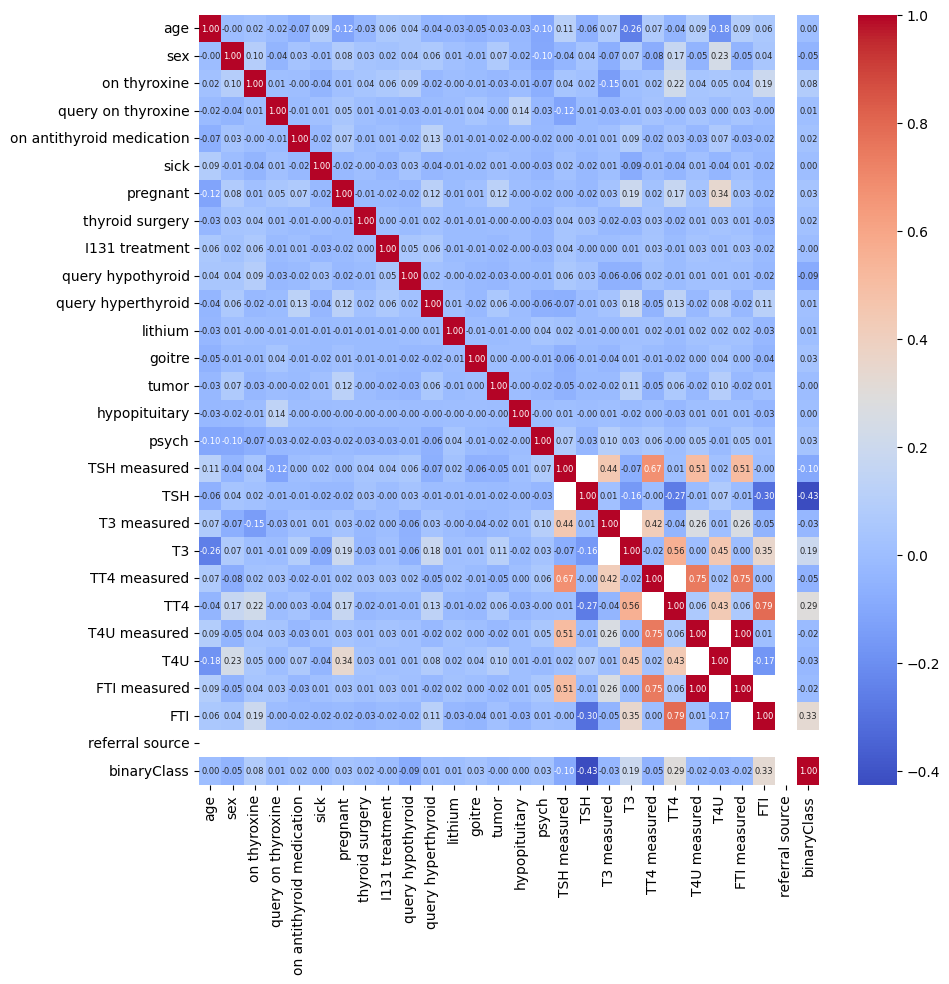

In [ ]:
#seleção das numericos apenas
df_pretratado_2 = df_pretratado_2.select_dtypes(include=['number'])
# calculo de correlação
corr = df_pretratado_2.corr()

# heatmap para visualzia a correlaçao
plt.figure(figsize=(10,10))
sns.heatmap(corr,  annot=True, fmt='.2f', cmap='coolwarm',annot_kws={'size': 6})

## Análise de Correlação - Heatmap Geral

### Principais Correlações com BinaryClass (Target)

- **TSH:** correlação negativa (-0.43), principal preditor. TSH baixo = positivo, confirmando hipertireoidismo
- **FTI:** correlação positiva (0.33), maior que TT4 isolado, sugere que o índice agrega informação
- **TT4:** correlação positiva (0.29), segundo hormônio mais correlacionado com o target

### Correlações Relevantes Entre Features

- **TSH measured x TT4 measured:** alta correlação, pacientes sem coleta de TSH tendem a não ter TT4 coletado também, reforçando hipótese de subgrupo de não coleta
- **T4U x pregnant:** correlação relevante, confirmando que T4U tem maior relevância em contexto de gravidez
- **FTI x TT4:** alta correlação esperada, FTI é derivado de TT4, multicolinearidade confirmada
- **FTI x T4U:** correlação relevante pela mesma razão

### Decisões Sugeridas pelo Heatmap

- **Manter FTI** em detrimento de TT4 e T4U isolados, por ter maior correlação com o target e agregar informação das duas variáveis
- **Investigar subgrupo de não coleta** via feature `num_exames_coletados`
- **Avaliar T4U em cruzamento com pregnant** antes de dropar

### Pendências

- Confirmar multicolinearidade FTI x TT4 x T4U com VIF na modelagem
- Testar hipóteses levantadas nas camadas anteriores

### Analise da correlação entre Psych e Lithium

In [ ]:
# groupby de psych
psych_group = df_pretratado_2.groupby('psych')[['TSH','T3','TT4']].mean()
# groupby de lithium
lithium_group = df_pretratado_2.groupby('lithium')[['TSH','T3','TT4']].mean()
display(psych_group, lithium_group)

,TSH,T3,TT4
psych,,,
0,5.27,2.01,108.32
1,1.95,2.11,108.26


,TSH,T3,TT4
lithium,,,
0,5.10,2.01,108.35
1,2.82,2.12,101.39


In [ ]:
# visualiza distribuição da variaveis
pd.crosstab(df['psych'], df['lithium'], normalize='index')

lithium,f,t
psych,,
f,1.00,0.00
t,0.98,0.02


In [ ]:
# groupby para visualizar a proporção de psych e lithium com releção a binaryclass
group = df_pretratado_2.groupby(['psych','lithium'])['binaryClass'].value_counts()
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_numbers = df_pretratado_2.groupby(['psych','lithium','binaryClass',])[['TSH','T3','TT4']].mean()
#visualiza os grupos
display(group, group_numbers)

psych  lithium  binaryClass
0      0        1              3291
                0               282
       1        1                14
                0                 1
1      0        1               173
                0                 8
       1        1                 3
Name: count, dtype: int64

TSH   T3    TT4
psych lithium binaryClass                  
0     0       0           40.19 1.47  72.41
              1            1.91 2.06 111.61
      1       0            7.90 2.20 104.00
              1            2.48 2.00 100.57
1     0       0            9.55 1.59  86.62
              1            1.58 2.12 109.33
      1       1            2.70 2.50 104.33

### Psych x Lithium - Análise de Confounding (Camada 4)

**Objetivo:** verificar se `psych` e `lithium` capturam informação hormonal similar ou se são grupos distintos.

**Sobreposição entre variáveis:**
- Apenas 2% dos pacientes com condição psiquiátrica usam lítio
- Praticamente nenhum paciente sem condição psiquiátrica usa lítio
- Grupos distintos, não redundantes diretamente

**Padrão hormonal por grupo:**

| Grupo | TSH médio (negativos) | Observação |
|-------|----------------------|------------|
| psych=0, lithium=0 | 40.19 | Referência, sem interferência |
| psych=0, lithium=1 | 7.90 | Lítio reduz TSH isoladamente |
| psych=1, lithium=0 | 9.55 | Condição psiquiátrica reduz TSH |
| psych=1, lithium=1 | 2.70 | Efeito combinado, maior redução |

**Conclusão:** ambas as variáveis interferem na função tireoidiana reduzindo o TSH. O efeito é independente e cumulativo.

**Decisão:**
- **psych:** manter. Tem sinal hormonal próprio com volume adequado
- **lithium:** não entra diretamente no modelo. Volume de 18 pacientes inviabiliza aprendizado confiável. Informação será testada via feature engineering em `psych_lithium_group`

**Hipótese de Feature Engineering:**
Criar variável `psych_lithium_group` com três categorias:
- `0`: sem condição psiquiátrica
- `1`: com condição psiquiátrica sem lítio
- `2`: com condição psiquiátrica com lítio

Captura a gradação do efeito hormonal observado. Testar na modelagem comparando com manter apenas `psych`. Volume baixo na categoria 2 (18 pacientes) pode limitar o ganho.

### Analise de sick e correlação binaryclass x TSH/T3/TT4

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_sick = df_pretratado_2.groupby(['sick','binaryClass',])[['TSH','T3','TT4']].mean()
# visualiza o grupo
display(group_sick)

TSH   T3    TT4
sick binaryClass                  
0    0           40.40 1.50  72.52
     1            1.90 2.07 111.76
1    0            9.54 1.00  82.73
     1            1.69 1.74 103.16

### Sick x Hormônios (Camada 4)

**Objetivo:** verificar se `sick=1` interfere nos valores hormonais dos pacientes negativos, criando confounding com o target.

**Resultado:**

| Grupo | TSH médio | T3 médio | TT4 médio |
|-------|-----------|----------|-----------|
| sick=0, negativo | 40.40 | 1.50 | 72.52 |
| sick=0, positivo | 1.90 | 2.07 | 111.76 |
| sick=1, negativo | 9.54 | 1.00 | 82.73 |
| sick=1, positivo | 1.69 | 1.74 | 103.16 |

**Hipótese confirmada:** pacientes com doença concomitante (`sick=1`) apresentam TSH significativamente mais baixo mesmo sendo negativos (9.54 vs 40.40). Isso pode confundir o modelo, que tende a associar TSH baixo com diagnóstico positivo.

**Risco:** falsos positivos em pacientes doentes e negativos.

**Mitigação:** `sick` deve permanecer no modelo como feature de contexto. Avaliar na modelagem se a combinação `sick + TSH` melhora a separação de falsos positivos.

### Analise de Pregnant e binaryclass x TSH/T3/TT4/T4U

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_preg = df_pretratado_2.groupby(['pregnant','binaryClass',])[['TSH','T3','TT4','T4U']].mean()
# visualiza o grupo
display(group_preg)

TSH   T3    TT4  T4U
pregnant binaryClass                       
0        0           39.23 1.47  72.92 1.01
         1            1.91 2.04 110.66 0.98
1        1            0.84 3.28 159.12 1.52


**Observações até agora:**
- Não existe `pregnant=1/negativo` na base: todas as grávidas são positivas
- T4U elevado em grávidas positivas (1.52) vs não grávidas positivas (0.98)
- Correlação T4U x pregnant confirmada pelo heatmap

**Questão em investigação:**
- T4U consegue substituir a informação de `pregnant`?
- Verificar se negativos também apresentam T4U alto, o que invalidaria a substituição

**Pendente:**
- Verificar distribuição de T4U dentro da classe negativa

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_t4u = df_pretratado_2.groupby(['binaryClass'])['T4U'].agg(['mean', 'max', 'count'])

# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_preg_t4u = df_pretratado_2.groupby(['pregnant'])['T4U'].agg(['mean', 'max', 'count'])

# visualiza o grupo
display(group_t4u,group_preg_t4u)

,mean,max,count
binaryClass,,,
0,1.01,1.65,266
1,0.99,2.32,3119


,mean,max,count
pregnant,,,
0,0.99,2.32,3333
1,1.52,2.01,52


### Pregnant x Hormônios (Camada 4)

**Objetivo:** verificar se `pregnant` tem relação com o target via exames hormonais ou diretamente.

**Resultado:**

| Grupo | TSH médio | T3 médio | TT4 médio | T4U médio |
|-------|-----------|----------|-----------|-----------|
| pregnant=0, negativo | 39.23 | 1.47 | 72.92 | 1.01 |
| pregnant=0, positivo | 1.91 | 2.04 | 110.66 | 0.98 |
| pregnant=1, positivo | 0.84 | 3.28 | 159.12 | 1.52 |

**Observações:**
- Não existe `pregnant=1/negativo` na base: todas as grávidas são positivas
- T4U elevado em grávidas positivas (1.52) vs não grávidas positivas (0.98), confirmando correlação do heatmap
- Negativos atingem T4U máximo de 1.65, com sobreposição nos valores de grávidas, (média= 1.52)

**Conclusão:** T4U não substitui `pregnant` pois negativos também atingem valores similares. Relação de `pregnant` com o target é direta, não apenas via hormônios.

**Risco:** leakage confirmado. 100% de grávidas positivas pode fazer o modelo aprender "grávida = positivo".

**Decisão:** `pregnant` não entra individualmente no modelo. Informação será incorporada via feature `risk_factors` junto com outras condições clínicas raras, diluindo o risco de leakage.

### Analise de I131 treatment e correlação binaryclass x TSH/T3/TT4

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_i131 = df_pretratado_2.groupby(['I131 treatment', 'binaryClass'])[['TSH','T3','TT4']].mean()
display(group_i131)

TSH   T3    TT4
I131 treatment binaryClass                  
0              0           39.41 1.47  73.07
               1            1.89 2.06 111.46
1              0           28.92 1.60  64.40
               1            2.05 2.11 109.74

### I131 Treatment x Hormônios (Camada 4)

**Objetivo:** verificar H2 - pacientes com tratamento I131 apresentam padrão de hipotireoidismo nos exames.

**Resultado:**

| Grupo | TSH médio | T3 médio | TT4 médio |
|-------|-----------|----------|-----------|
| I131=0, negativo | 39.41 | 1.47 | 73.07 |
| I131=0, positivo | 1.89 | 2.06 | 111.46 |
| I131=1, negativo | 28.92 | 1.60 | 64.40 |
| I131=1, positivo | 2.05 | 2.11 | 109.74 |

**H2 parcialmente refutada:** TSH levemente mais baixo em `I131=1/negativo` (28.92 vs 39.41), mas não o padrão extremo de hipotireoidismo severo esperado. Positivos com I131 têm padrão hormonal praticamente idêntico aos sem I131.

**Decisão:** drop. Poder preditivo nulo confirmado na camada 3, H2 parcialmente refutada, sem hipótese de interação hormonal que justifique manter.

### Analise Subgrupos nao measureds

In [ ]:
# separação de mesuared = 0

df_nao_measured = df_pretratado_2[df_pretratado_2['TSH measured'] == 0]

In [ ]:
# visualiza padrao de distribuição dentro do grupo nao medido
df_nao_measured.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,referral source,binaryClass
count,369.00,369.00,369.00,369.00,369.00,369.00,369.00,369.00,369.00,369.00,...,369.00,93.00,369.00,166.00,369.00,159.00,369.00,159.00,0.00,369.00
mean,45.33,0.75,0.08,0.05,0.01,0.03,0.01,0.00,0.00,0.02,...,0.25,2.36,0.45,107.45,0.43,0.98,0.43,110.50,NaN,1.00
std,18.77,0.43,0.27,0.23,0.10,0.17,0.12,0.00,0.00,0.15,...,0.43,1.02,0.50,34.43,0.50,0.18,0.50,34.97,NaN,0.00
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.70,0.00,52.00,0.00,0.53,0.00,49.00,NaN,1.00
25%,30.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.80,0.00,86.00,0.00,0.88,0.00,90.00,NaN,1.00
50%,46.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,2.20,0.00,98.00,0.00,0.96,0.00,103.00,NaN,1.00
75%,60.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,2.70,1.00,120.00,1.00,1.06,1.00,120.50,NaN,1.00
max,89.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,1.00,...,1.00,6.60,1.00,248.00,1.00,1.88,1.00,280.00,NaN,1.00


In [ ]:
# visualiza padrao de distribuição dentro do grupo nao medido
df_nao_measured.agg(['mean','count']).T

,mean,count
age,45.33,369.00
sex,0.75,369.00
on thyroxine,0.08,369.00
query on thyroxine,0.05,369.00
on antithyroid medication,0.01,369.00
sick,0.03,369.00
pregnant,0.01,369.00
thyroid surgery,0.00,369.00
I131 treatment,0.00,369.00
query hypothyroid,0.02,369.00


In [ ]:
# separação de mesuared = 0 em df_pretatado para visualizar referal source

df_nao_measured_group = df_pretratado[df_pretratado['TSH measured'] == 'f']

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_source = df_nao_measured_group.groupby(['referral source','binaryClass',])[['TSH measured',
                                                              'T3 measured',
                                                              'TT4 measured',
                                                              'T4U measured',]].value_counts()
display(group_source)

referral source  binaryClass  TSH measured  T3 measured  TT4 measured  T4U measured
STMW             P            f             t            t             t                 1
SVHC             P            f             f            f             f                 1
                                                         t             t                 1
SVI              P            f             t            t             f                 2
                                                                       t                 2
                                            f            t             t                 1
                                            t            f             f                 1
other            P            f             f            f             f               178
                                                         t             t                94
                                            t            t             t                60
                                                         f             f                23
                                                         t             f                 4
                                            f            t             f                 1
Name: count, dtype: int64

### Subgrupos de Não Coleta (Camada 4)

**Objetivo:** investigar o perfil dos pacientes sem coleta dos exames principais para entender se a ausência de medição carrega sinal preditivo real ou é leakage.

**Padrão encontrado:**

| Exame não coletado | Volume | % Positivo |
|-------------------|--------|------------|
| TSH measured = f | 369 | 100% |
| TT4 measured = f | 231 | 98% |
| T3 measured = f | 769 | 94% |

**Origem dos pacientes sem TSH:** 97% vêm de `other`, categoria guarda-chuva de atendimento geral não especializado. Não foi possível identificar padrão clínico específico que explique a não coleta.

**Hipótese:** pacientes sem coleta dos exames principais chegaram com diagnóstico já estabelecido por outros meios, dispensando confirmação laboratorial.

**Trade-off da feature `num_exames_coletados`:**
- Sinal consistente: quanto menos exames coletados, maior a taxa de positivos
- Risco de leakage: se a não coleta é decisão pós-diagnóstico, a feature vaza informação do target

**Decisão:** criar a feature e testar na modelagem. Avaliar impacto no modelo com e sem ela. Se gerar ganho desproporcional de métrica, indica leakage e deve ser removida.

**Achados adicionais no perfil do grupo sem TSH:**
- `query hyperthyroid` em 11% vs 6.28% na base geral: dobro de suspeita de hipertireoidismo
- `on thyroxine` em 8% vs 12.3% na base geral: menos pacientes em tratamento para hipotireoidismo
- Ambos os achados reforçam que esses pacientes têm perfil de hipertireoidismo já estabelecido, dispensando TSH como triagem

### Analise de thyroid surgery e binary Class X TSH/T3/TT4

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_surgery = df_pretratado_2.groupby(['thyroid surgery','binaryClass',])[['TSH','T3','TT4']].mean()
# visualiza o grupo
display(group_surgery)

TSH   T3    TT4
thyroid surgery binaryClass                  
0               0           39.07 1.47  72.98
                1            1.79 2.06 111.56
1               0           63.50 2.10  64.00
                1            8.11 1.80 103.51

### Thyroid Surgery x Hormônios (Camada 4)

**Objetivo:** verificar se histórico de cirurgia na tireoide altera o padrão hormonal dos pacientes.

**Resultado:**

| Grupo | TSH médio | T3 médio | TT4 médio |
|-------|-----------|----------|-----------|
| thyroid surgery=0, negativo | 39.07 | 1.47 | 72.98 |
| thyroid surgery=0, positivo | 1.79 | 2.06 | 111.56 |
| thyroid surgery=1, negativo | 63.50 | 2.10 | 64.00 |
| thyroid surgery=1, positivo | 8.11 | 1.80 | 103.51 |

**Hipótese confirmada:** cirurgia na tireoide eleva o TSH em ambas as classes. Negativos operados têm TSH de 63.50 vs 39.07 sem cirurgia. Positivos operados têm TSH de 8.11 vs 1.79 sem cirurgia.

**Efeito oposto ao sick:** enquanto `sick` reduz o TSH, `thyroid surgery` eleva. Isso cria perfis hormonais distintos que o modelo precisa diferenciar.

**Risco:** paciente operado e positivo tem TSH mais alto que o típico positivo, podendo ser classificado erroneamente como negativo pelo modelo.

**Decisão:** manter individualmente no modelo para que o modelo capture o padrão de TSH elevado por cirurgia. Incluir também em `risk_factors` para contexto de risco clínico.

### Analise de goitre e binary Class X TSH/T3/TT4

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_surgery = df_pretratado_2.groupby(['goitre','binaryClass',])[['TSH','T3','TT4']].mean()
# visualiza o grupo
display(group_surgery)

TSH   T3    TT4
goitre binaryClass                  
0      0           39.23 1.47  72.92
       1            1.90 2.06 111.53
1      1            1.16 2.15 100.81

### Goitre x Hormônios (Camada 4)

**Objetivo:** verificar padrão hormonal dos pacientes com bócio antes de confirmar drop.

**Resultado:**

| Grupo | TSH médio | T3 médio | TT4 médio |
|-------|-----------|----------|-----------|
| goitre=0, negativo | 39.23 | 1.47 | 72.92 |
| goitre=0, positivo | 1.90 | 2.06 | 111.53 |
| goitre=1, positivo | 1.16 | 2.15 | 100.81 |

**Observação:** não existe `goitre=1/negativo`. Todos os 34 pacientes com bócio são positivos.

**Padrão hormonal:** similar ao positivo sem bócio. TSH baixo, T3 levemente mais alto.

**Decisão:** não entra individualmente no modelo. Volume de 34 pacientes com 100% positivo levanta risco de leakage. Informação preservada via `risk_factors`.

### Analise de tumor e binary Class X TSH/T3/TT4

In [ ]:
# groupby para visualizar a proporção dos grupos em relação aos numeros dos exames
group_surgery = df_pretratado_2.groupby(['tumor','binaryClass',])[['TSH','T3','TT4']].mean()
# visualiza o grupo
display(group_surgery)

TSH   T3    TT4
tumor binaryClass                  
0     0           39.86 1.45  72.82
      1            1.91 2.05 111.05
1     0           17.00 2.20  76.38
      1            0.97 2.65 127.75

### Tumor x Hormônios (Camada 4)

**Objetivo:** verificar padrão hormonal dos pacientes com tumor antes de confirmar drop.

**Resultado:**

| Grupo | TSH médio | T3 médio | TT4 médio |
|-------|-----------|----------|-----------|
| tumor=0, negativo | 39.86 | 1.45 | 72.82 |
| tumor=0, positivo | 1.91 | 2.05 | 111.05 |
| tumor=1, negativo | 17.00 | 2.20 | 76.38 |
| tumor=1, positivo | 0.97 | 2.65 | 127.75 |

**Observação:** tumor reduz o TSH em ambas as classes, padrão similar ao `sick`. Apenas 8 negativos com tumor, volume insuficiente para o modelo aprender o padrão com confiança.

**Decisão:** não entra individualmente no modelo. Volume baixo e risco de confounding. Informação preservada via `risk_factors`.

### Multicolinearidade FTI x TT4 x T4U (Camada 4)

**Correlações identificadas no heatmap:**

| Par | Correlação |
|-----|-----------|
| FTI x TT4 | 0.79 |
| T4U x TT4 | 0.49 |
| FTI x T4U | -0.17 |

**Correlação com o target (binaryClass):**
- FTI: 0.33
- TT4: 0.29
- T4U: baixa

**Análise de T4U x Pregnant:**
- T4U tem correlação de 0.34 com `pregnant`
- FTI tem correlação de -0.02 com `pregnant`
- T4U captura sinal específico de gravidez que FTI não captura

**Decisões:**
- **FTI:** manter. Maior correlação com o target e incorpora matematicamente TT4/T4U
- **TT4:** dropar. Alta multicolinearidade com FTI (0.79), informação já capturada por FTI
- **T4U:** manter. Captura sinal específico de gravidez que FTI não captura, mesmo com `pregnant` sendo incorporada via `risk_factors`

# Síntese da Camada 4 - Análise Multivariada

### Análises Realizadas

| Análise | Resultado |
|---------|-----------|
| psych x lithium | Grupos distintos, efeito hormonal similar mas independente |
| sick x hormônios | Confirmado confounding: reduz TSH em negativos |
| pregnant x hormônios | 100% positivas, leakage confirmado, T4U captura sinal parcialmente |
| thyroid surgery x hormônios | Eleva TSH, efeito oposto ao sick |
| I131 treatment x hormônios | H2 parcialmente refutada, drop confirmado |
| goitre x hormônios | 100% positivos, drop individual confirmado |
| tumor x hormônios | Reduz TSH similar ao sick, volume insuficiente |
| subgrupos de não coleta | 100% positivos sem TSH, perfil de hipertireoidismo estabelecido |
| multicolinearidade FTI/TT4/T4U | FTI e T4U mantidos, TT4 dropado |

### Decisões Finais de Features

**Manter individualmente:**
- TSH, T3, FTI, T4U
- on thyroxine, on antithyroid medication
- query hypothyroid, sick, thyroid surgery, psych
- sex, age, referral source
- TSH measured, TT4 measured, T3 measured, T4U measured, FTI measured

**Drop confirmado:**
- TT4: multicolinearidade com FTI
- I131 treatment: poder preditivo nulo, H2 refutada
- query on thyroxine: categoria rara, baixo poder preditivo
- hypopituitary: 1 paciente
- lithium: volume inviável, informação via psych_lithium_group

**Drop individual, manter em risk_factors:**
- pregnant, goitre, tumor

### Features de Engineering Propostas

| Feature | Variáveis | Objetivo |
|---------|-----------|----------|
| `risk_factors` | pregnant, sick, thyroid surgery, goitre, tumor | Perfil de risco clínico agregado |
| `psych_lithium_group` | psych, lithium | Gradação do efeito psiquiátrico no TSH |
| `num_exames_coletados` | todas as measured | Perfil de coleta laboratorial |

### Riscos Documentados

- **Leakage potencial:** on thyroxine, pregnant, TSH measured, TT4 measured
- **Confounding:** sick e thyroid surgery têm efeitos opostos no TSH
- **Unidades de medida:** não confirmadas, risco em produção
- **Desbalanceamento:** 92.29% positivo, requer SMOTE ou class_weight na modelagem

## Conclusão do EDA - Diagnóstico de Hipertireoidismo

### Questão Central Respondida

O dataset representa **hipertireoidismo**, não hipotireoidismo como indica o nome do arquivo. Confirmado pelo TSH baixo na classe positiva (mediana P=1.2 vs N=12.0).

### Principais Achados

**Preditor principal:** TSH é o principal discriminante com correlação de -0.43 com o target e mediana 10x maior em negativos vs positivos.

**Dataset:** 3.772 pacientes, 30 variáveis originais, target `binaryClass` com desbalanceamento severo de 92.29% positivo.

**Qualidade dos dados:** valores ausentes nos exames laboratoriais são informativos (decisão médica de não coletar), não aleatórios.

### Decisões de Feature Engineering

- **`risk_factors`:** agrega condições clínicas raras e com leakage (pregnant, sick, thyroid surgery, goitre, tumor)
- **`psych_lithium_group`:** captura gradação do efeito psiquiátrico no TSH
- **`num_exames_coletados`:** captura perfil de coleta laboratorial

### Variáveis para Modelagem

**Mantidas:** TSH, T3, FTI, T4U, on thyroxine, on antithyroid medication, query hypothyroid, sick, thyroid surgery, psych, sex, age, referral source, TSH measured, TT4 measured, T3 measured, T4U measured, FTI measured

**Dropadas:** TT4, I131 treatment, query on thyroxine, hypopituitary, lithium, pregnant, goitre, tumor (últimas três via risk_factors)

### Riscos e Limitações

- Unidades de medida dos exames não confirmadas, risco em produção
- Leakage potencial em on thyroxine, TSH measured e TT4 measured
- Desbalanceamento severo requer tratamento na modelagem (SMOTE ou class_weight)
- Confounding em sick e thyroid surgery: efeitos opostos no TSH

### Próximos Passos

- Notebook `02_preprocessing`: encoding, scaling, tratamento de nulos informativos, criação das features de engineering
- Notebook `03_training`: testar modelos com e sem features de engineering, avaliar impacto do leakage
- Notebook `04_evaluation`: priorizar F1-score, Recall e AUC-ROC dado o desbalanceamento